# Prediksi Tiket Bioskop D4–D10 — Target MASE < 0.5

## Ide inti (kenapa pendekatan ini bisa menembus MASE rendah)

Metrik MASE membagi setiap error dengan `scale`, yaitu rata-rata tiket D1–D3 untuk
pasangan (film × klaster) yang sama:

$$\text{MASE}=\frac{1}{N}\sum_i \frac{|y_i-\hat y_i|}{scale_{p(i)}}
        = \frac{1}{N}\sum_i \left| \frac{y_i}{scale_{p(i)}} - \frac{\hat y_i}{scale_{p(i)}} \right|$$

Jadi MASE **identik** dengan MAE pada skala rasio. Konsekuensi desain:

1. **Target model = rasio** `y / scale`, bukan jumlah tiket mentah. Ini menghapus
   perbedaan skala antar klaster besar/kecil, sehingga satu model bisa belajar
   *bentuk kurva permintaan* dari semua pasangan sekaligus.
2. **Loss = L1 (MAE)**. Dengan target rasio, loss training **sama persis** dengan
   metrik kompetisi — tidak ada mismatch objective/metric.
3. Prediksi akhir = `rasio_prediksi × scale`.
4. L1 memprediksi **median kondisional**, yang secara alami mengeluarkan nilai 0
   saat pasangan kemungkinan besar sudah turun layar. Ini penting karena banyak
   baris D4–D10 bernilai nol.

**Aturan fitur yang dipegang ketat:** saat memprediksi, kita hanya punya D1–D3 +
metadata + kalender. Maka **tidak ada** fitur yang butuh informasi setelah D3
(termasuk umur film, `occupation_rate` / `total_show` hari target, dsb).

## 1. Setup & Load Data

In [1]:
import os
import re
import gc
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

SEED = 2026
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True


def find_data_dir():
    """Cari folder yang memuat train.csv (Kaggle / lokal)."""
    cands = [os.environ.get("DATA_DIR", ""), "./data", "../data", "."]
    cands += sorted(glob.glob("/kaggle/input/*"))
    cands += sorted(glob.glob("/kaggle/input/*/*"))
    for p in cands:
        if p and os.path.exists(os.path.join(p, "train.csv")):
            return p
    raise FileNotFoundError(
        "train.csv tidak ditemukan. Set environment variable DATA_DIR "
        "atau tambahkan dataset kompetisi ke notebook."
    )


DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR)

_rd = lambda f: pd.read_csv(os.path.join(DATA_DIR, f))

train = _rd("train.csv")
test_history = _rd("test_history.csv")
test = _rd("test.csv")
movies = _rd("movies.csv")
holidays = _rd("holidays.csv")
ticket_prices = _rd("ticket_prices.csv")
sample_submission = _rd("sample_submission.csv")

# --- normalisasi tipe dasar -------------------------------------------------
for _d in (train, test_history, test):
    _d["date_show"] = pd.to_datetime(_d["date_show"])
    _d["cinema_ids"] = _d["cinema_ids"].astype(str).str.strip()
    _d["movie_title"] = _d["movie_title"].astype(str).str.strip()
    _d["city_name"] = _d["city_name"].astype(str).str.strip()

holidays["date"] = pd.to_datetime(holidays["date"])
for _c in ("day_tipe", "holiday_tipe"):
    holidays[_c] = holidays[_c].astype(str).str.strip().str.lower()

ticket_prices["city_name"] = ticket_prices["city_name"].astype(str).str.strip()
ticket_prices["price_day"] = ticket_prices["price_day"].astype(str).str.strip().str.lower()

for _n, _d in [
    ("train", train), ("test_history", test_history), ("test", test),
    ("movies", movies), ("holidays", holidays),
    ("ticket_prices", ticket_prices), ("sample_submission", sample_submission),
]:
    print(f"{_n:<18s} {str(_d.shape):>14s}   kolom: {list(_d.columns)}")

print("\n--- train.head() ---")
print(train.head())

DATA_DIR = .
train                 (138959, 7)   kolom: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test_history           (32323, 7)   kolom: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test                   (72611, 5)   kolom: ['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']
movies                   (397, 7)   kolom: ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts']
holidays                 (366, 4)   kolom: ['date', 'day_tipe', 'holiday_tipe', 'holiday_name']
ticket_prices            (207, 3)   kolom: ['city_name', 'ceil', 'price_day']
sample_submission      (72611, 2)   kolom: ['id', 'total_ticket']

--- train.head() ---
   date_show                        cinema_ids city_name                       movie_title  total_ticket  occupation_rate  total_show
0 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA      

## 2. Pemeriksaan Struktur D1–D3 / D4–D10

Cell ini memverifikasi asumsi yang dipakai seluruh pipeline dan **menetapkan
beberapa config otomatis** dari data (mis. apakah `test.csv` memuat pasangan yang
sama sekali tidak punya transaksi di D1–D3). Baca output-nya; kalau ada assertion
yang gagal, itu sinyal bahwa asumsi struktur perlu disesuaikan.

In [2]:
# ---------------------------------------------------------------- D1 per film uji
_g = test_history.groupby("movie_title")["date_show"]
d1_map = _g.min().rename("d1").reset_index()

_chk = _g.agg(n_dates="nunique", dmin="min", dmax="max").reset_index()
_chk["span_days"] = (_chk["dmax"] - _chk["dmin"]).dt.days + 1
print("Jumlah film uji di test_history :", _chk.shape[0])
print("Jumlah film uji di test.csv     :", test["movie_title"].nunique())
print("\nDistribusi jumlah tanggal unik per film di test_history (harap 3):")
print(_chk["n_dates"].value_counts().sort_index())
print("\nDistribusi span tanggal D1..D3 (harap 3 = tiga hari berurutan):")
print(_chk["span_days"].value_counts().sort_index())
print("\nRentang tanggal test_history :", test_history["date_show"].min().date(), "->", test_history["date_show"].max().date())
print("Rentang tanggal test         :", test["date_show"].min().date(), "->", test["date_show"].max().date())
print("Rentang tanggal train        :", train["date_show"].min().date(), "->", train["date_show"].max().date())

# ------------------------------------------------- offset hari (D1 = 1 .. D10 = 10)
test = test.merge(d1_map, on="movie_title", how="left")
print("\nBaris test tanpa pasangan d1 (film tak ada di test_history):", int(test["d1"].isna().sum()))
test["off"] = (test["date_show"] - test["d1"]).dt.days + 1

print("\nDistribusi offset hari pada test.csv (harap hanya 4..10):")
print(test["off"].value_counts().sort_index())

_rows_per_pair = test.groupby(["movie_title", "cinema_ids"]).size()
print("\nBaris per pasangan film×klaster di test.csv (harap semuanya 7):")
print(_rows_per_pair.value_counts())

# ------------------------------------------------------------------- duplikasi
for _n, _d in [("train", train), ("test_history", test_history)]:
    _dup = _d.groupby(["movie_title", "cinema_ids", "date_show"]).size()
    print(f"\n{_n}: max baris per (film, klaster, tanggal) = {int(_dup.max())} "
          f"| jumlah kombinasi duplikat = {int((_dup > 1).sum())}")

# --------------------------------------- pasangan test yang tak punya riwayat D1-D3
_pairs_test = set(map(tuple, test[["movie_title", "cinema_ids"]].drop_duplicates().values))
_pairs_hist = set(map(tuple, test_history[["movie_title", "cinema_ids"]].drop_duplicates().values))
_no_hist = _pairs_test - _pairs_hist
SHARE_NO_HISTORY = len(_no_hist) / max(len(_pairs_test), 1)
print(f"\nPasangan unik di test.csv      : {len(_pairs_test)}")
print(f"Pasangan unik di test_history  : {len(_pairs_hist)}")
print(f"Pasangan test TANPA riwayat D1-D3: {len(_no_hist)} ({SHARE_NO_HISTORY:.2%})")
print(f"Pasangan di test_history tapi TIDAK diprediksi: {len(_pairs_hist - _pairs_test)}")

Jumlah film uji di test_history : 163
Jumlah film uji di test.csv     : 160

Distribusi jumlah tanggal unik per film di test_history (harap 3):
n_dates
1      1
2      2
3    160
Name: count, dtype: int64

Distribusi span tanggal D1..D3 (harap 3 = tiga hari berurutan):
span_days
1      1
2      2
3    160
Name: count, dtype: int64

Rentang tanggal test_history : 2025-10-01 -> 2026-03-20
Rentang tanggal test         : 2025-10-04 -> 2026-03-27
Rentang tanggal train        : 2025-04-01 -> 2025-09-30

Baris test tanpa pasangan d1 (film tak ada di test_history): 0

Distribusi offset hari pada test.csv (harap hanya 4..10):
off
4     10373
5     10373
6     10373
7     10373
8     10373
9     10373
10    10373
Name: count, dtype: int64

Baris per pasangan film×klaster di test.csv (harap semuanya 7):
7    10373
Name: count, dtype: int64

train: max baris per (film, klaster, tanggal) = 1 | jumlah kombinasi duplikat = 0

test_history: max baris per (film, klaster, tanggal) = 1 | jumlah kombinasi

### Mengapa pasangan tanpa riwayat itu berbahaya
Kalau sebuah pasangan tidak punya transaksi D1–D3 maka `scale = max(0/3, 1) = 1`,
sehingga **setiap 1 tiket error = 1 poin MASE** untuk baris tersebut. Beberapa ratus
baris seperti ini bisa mendominasi skor total. Karena itu konstruksi data latih
di bawah ikut menyertakan pasangan semacam itu (lihat `INCLUDE_FUTURE_ONLY_PAIRS`),
agar model punya contoh dan tidak "menebak buta".

In [3]:
# konsistensi: apakah film uji juga muncul di train? (idealnya tidak / sedikit)
_ov_movies = set(test["movie_title"]) & set(train["movie_title"])
print(f"\nFilm uji yang juga ada di train.csv : {len(_ov_movies)} dari {test['movie_title'].nunique()}")
if _ov_movies:
    print("  contoh:", list(_ov_movies)[:5])

# klaster: harus tumpang tindih tinggi, karena fitur statis klaster dibangun dari train
_cl_test = set(test["cinema_ids"])
_cl_train = set(train["cinema_ids"])
print(f"Klaster di test  : {len(_cl_test)} | juga di train: {len(_cl_test & _cl_train)} "
      f"| TIDAK di train: {len(_cl_test - _cl_train)}")
_ct_test = set(test["city_name"])
print(f"Kota di test     : {len(_ct_test)} | juga di train: {len(_ct_test & set(train['city_name']))}")

# ------------------------------------------------------------------- missing value
print("\nMissing value train:\n", train.isna().sum().to_string())
print("\nStatistik target train:\n", train["total_ticket"].describe().to_string())
print("\nNilai total_ticket <= 0 di train:", int((train["total_ticket"] <= 0).sum()))

# ------------------------------------------------- hari-dalam-minggu untuk D1 film uji
d1_map["d1_dow"] = d1_map["d1"].dt.dayofweek  # 0=Senin .. 6=Minggu
_DOW_ID = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
print("\nHari D1 film uji (penting untuk memilih anchor data latih):")
print(d1_map["d1_dow"].map(dict(enumerate(_DOW_ID))).value_counts())

TEST_D1_DOWS = sorted(d1_map["d1_dow"].unique().tolist())
print("TEST_D1_DOWS =", TEST_D1_DOWS)

# ----------------------------------------------------------------- CONFIG otomatis
INCLUDE_FUTURE_ONLY_PAIRS = SHARE_NO_HISTORY > 0.001
print("\n>>> CONFIG INCLUDE_FUTURE_ONLY_PAIRS =", INCLUDE_FUTURE_ONLY_PAIRS)

assert test["off"].between(4, 10).all(), "Ada baris test di luar rentang D4-D10!"
assert (_rows_per_pair == 7).all(), "Ada pasangan test yang tidak tepat 7 baris!"
assert set(test["id"]) == set(sample_submission["id"]), "id test vs sample_submission tidak sama!"
print("\nSemua assertion struktur LOLOS.")


Film uji yang juga ada di train.csv : 10 dari 160
  contoh: ['AIR MATA DI UJUNG SAJADAH 2', 'JANGAN PANGGIL MAMA KAFIR', 'THE STRANGERS: CHAPTER 2', 'TUKAR TAKDIR', 'RANGGA & CINTA']
Klaster di test  : 121 | juga di train: 117 | TIDAK di train: 4
Kota di test     : 69 | juga di train: 67

Missing value train:
 date_show          0
cinema_ids         0
city_name          0
movie_title        0
total_ticket       0
occupation_rate    0
total_show         0

Statistik target train:
 count    138959.000000
mean        354.122072
std         725.927987
min           1.000000
25%          69.000000
50%         161.000000
75%         361.000000
max       32845.000000

Nilai total_ticket <= 0 di train: 0

Hari D1 film uji (penting untuk memilih anchor data latih):
d1_dow
Rabu      67
Kamis     65
Jumat     24
Sabtu      5
Selasa     2
Name: count, dtype: int64
TEST_D1_DOWS = [1, 2, 3, 4, 5]

>>> CONFIG INCLUDE_FUTURE_ONLY_PAIRS = False

Semua assertion struktur LOLOS.


## 3. EDA — Melihat Bentuk Masalah dalam Satuan Metrik

EDA di sini sengaja tidak berhenti di "distribusi tiket". Yang paling berguna adalah
melihat data **dalam satuan yang dinilai**, yaitu rasio `y / scale`, karena itulah
yang harus diprediksi model. Dari situ langsung terbaca: berapa MASE dari tebakan
naif, seberapa besar peluruhan permintaan per horizon, dan berapa porsi baris nol.

Pasangan film×klaster untuk EDA: 5,137 (dari 227 film)


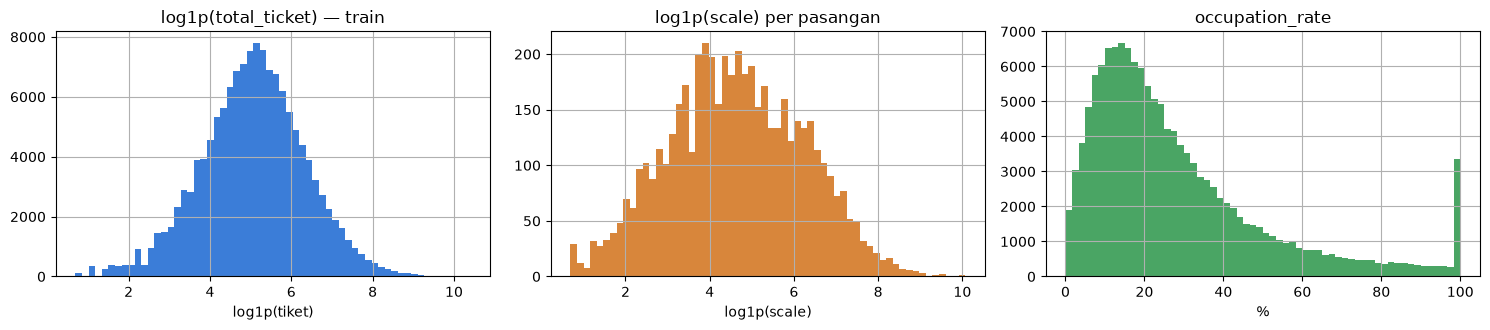


Sebaran scale (rata-rata tiket D1-D3 per pasangan):
count     5137.000000
mean       343.810006
std        816.638814
min          1.000000
10%         11.333333
25%         31.000000
50%         98.000000
75%        332.000000
90%        844.400000
99%       3621.173333
max      23587.000000

Porsi pasangan dengan scale <= 3 tiket/hari: 1.8%
  -> pasangan kecil ini bobotnya sama dengan pasangan besar di MASE,
     jadi model TIDAK boleh dilatih pada tiket mentah (MAE mentah akan mengabaikannya).

Rasio y/scale per horizon (inilah target model):
    mean_rasio  median_rasio  p10    p90  porsi_nol
h                                                  
4        1.008         0.935  0.0  2.158      0.332
5        1.189         0.976  0.0  2.640      0.329
6        1.235         0.638  0.0  2.661      0.360
7        1.194         0.538  0.0  2.678      0.362
8        1.103         0.385  0.0  2.380      0.396
9        1.061         0.226  0.0  2.268      0.464
10       0.824         0.000  0

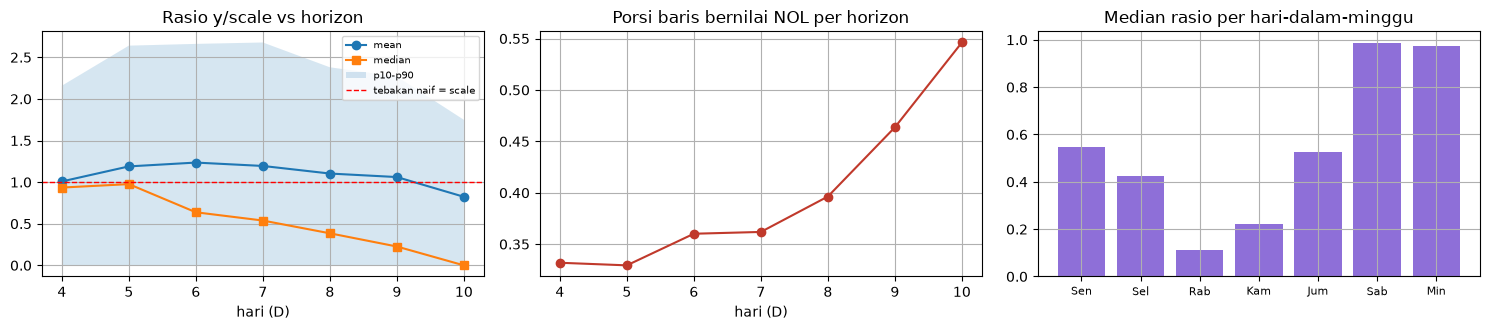

In [4]:
# ---- jendela EDA: anchor = tanggal pertama film muncul di train ------------------
_TRAIN_MAX = train["date_show"].max()
_mfirst = train.groupby("movie_title")["date_show"].min().rename("m_d1").reset_index()
_mfirst = _mfirst[_mfirst["m_d1"] + pd.Timedelta(days=9) <= _TRAIN_MAX]  # jendela lengkap saja

_e = train.merge(_mfirst, on="movie_title")
_e["off"] = (_e["date_show"] - _e["m_d1"]).dt.days + 1
_e = _e[_e["off"].between(1, 10)]

_piv = _e.pivot_table(index=["movie_title", "cinema_ids"], columns="off",
                      values="total_ticket", aggfunc="sum")
_piv = _piv.reindex(columns=range(1, 11)).fillna(0.0)   # tak ada transaksi = 0 tiket
_piv.columns = [f"s{c}" for c in _piv.columns]
_piv = _piv.reset_index()

_piv["scale"] = np.maximum((_piv["s1"] + _piv["s2"] + _piv["s3"]) / 3.0, 1.0)
_piv = _piv[_piv[[f"s{i}" for i in (1, 2, 3)]].sum(axis=1) > 0]  # ada riwayat D1-D3
print(f"Pasangan film×klaster untuk EDA: {len(_piv):,} (dari {_piv['movie_title'].nunique()} film)")

# ---- 1. sebaran tiket harian & sebaran scale ------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].hist(np.log1p(train["total_ticket"]), bins=60, color="#3b7dd8")
ax[0].set_title("log1p(total_ticket) — train"); ax[0].set_xlabel("log1p(tiket)")
ax[1].hist(np.log1p(_piv["scale"]), bins=60, color="#d8863b")
ax[1].set_title("log1p(scale) per pasangan"); ax[1].set_xlabel("log1p(scale)")
ax[2].hist(train["occupation_rate"].dropna(), bins=60, color="#4aa564")
ax[2].set_title("occupation_rate"); ax[2].set_xlabel("%")
plt.tight_layout(); plt.show()

print("\nSebaran scale (rata-rata tiket D1-D3 per pasangan):")
print(_piv["scale"].describe(percentiles=[.1, .25, .5, .75, .9, .99]).to_string())
print(f"\nPorsi pasangan dengan scale <= 3 tiket/hari: {(_piv['scale'] <= 3).mean():.1%}")
print("  -> pasangan kecil ini bobotnya sama dengan pasangan besar di MASE,")
print("     jadi model TIDAK boleh dilatih pada tiket mentah (MAE mentah akan mengabaikannya).")

# ---- 2. kurva peluruhan dalam satuan rasio -------------------------------------
_ratio = pd.DataFrame({
    "h": np.repeat(np.arange(4, 11), len(_piv)),
    "r": np.concatenate([(_piv[f"s{h}"] / _piv["scale"]).values for h in range(4, 11)]),
    "dow": np.concatenate([
        ((_piv["movie_title"].map(_mfirst.set_index("movie_title")["m_d1"])
          + pd.to_timedelta(h - 1, unit="D")).dt.dayofweek).values
        for h in range(4, 11)
    ]),
})
_summary = _ratio.groupby("h")["r"].agg(
    mean_rasio="mean", median_rasio="median",
    p10=lambda s: s.quantile(.10), p90=lambda s: s.quantile(.90),
    porsi_nol=lambda s: float((s == 0).mean()),
)
print("\nRasio y/scale per horizon (inilah target model):")
print(_summary.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].plot(_summary.index, _summary["mean_rasio"], "o-", label="mean")
ax[0].plot(_summary.index, _summary["median_rasio"], "s-", label="median")
ax[0].fill_between(_summary.index, _summary["p10"], _summary["p90"], alpha=.18, label="p10-p90")
ax[0].axhline(1.0, color="r", ls="--", lw=1, label="tebakan naif = scale")
ax[0].set_title("Rasio y/scale vs horizon"); ax[0].set_xlabel("hari (D)"); ax[0].legend(fontsize=7)
ax[1].plot(_summary.index, _summary["porsi_nol"], "o-", color="#c0392b")
ax[1].set_title("Porsi baris bernilai NOL per horizon"); ax[1].set_xlabel("hari (D)")
_dowmed = _ratio.groupby("dow")["r"].median()
ax[2].bar(_dowmed.index, _dowmed.values, color="#8e6fd8")
ax[2].set_xticks(range(7)); ax[2].set_xticklabels(["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"], fontsize=8)
ax[2].set_title("Median rasio per hari-dalam-minggu")
plt.tight_layout(); plt.show()

**Cara membaca:** garis merah putus-putus adalah prediksi naif "besok = rata-rata D1–D3".
Jarak rata-rata antara sebaran rasio dan garis itu **adalah** MASE dari baseline naif.
Dua sumber sinyal terbesar yang bisa dieksploitasi terlihat jelas: (a) peluruhan
sistematis terhadap horizon, dan (b) musiman hari-dalam-minggu (akhir pekan naik tajam).

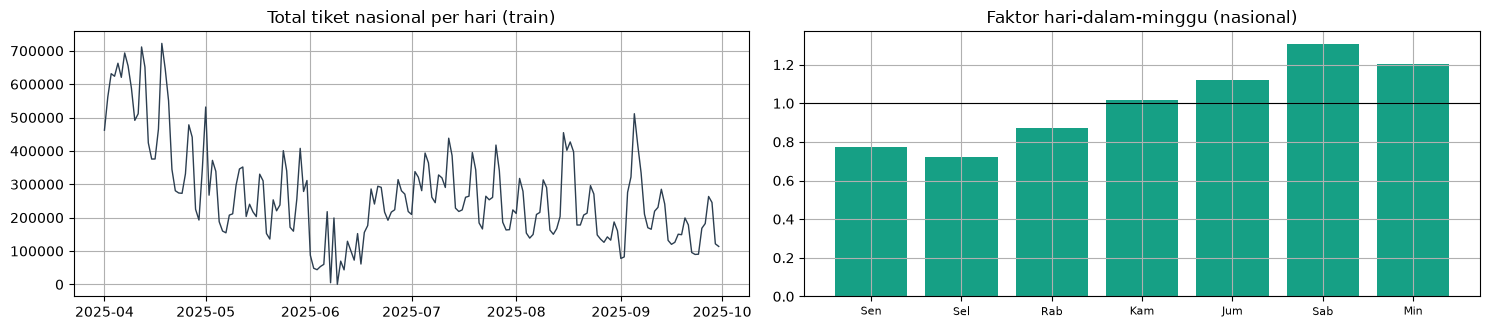


Rata-rata tiket nasional harian per (day_tipe, holiday_tipe):
                           mean  size
day_tipe holiday_tipe                
friday   holiday       441437.0     4
         normal        275870.0    21
weekday  holiday       438288.0     4
         normal        220285.0   101
weekend  holiday       354850.0     3
         normal        338428.0    49

Jumlah klaster di train: 117
Rata-rata tiket harian per klaster:
count      117.0
mean      2358.7
std       2923.5
min         45.9
10%        538.9
50%       1519.6
90%       5344.9
max      22593.4
Rasio klaster terbesar/terkecil: 492x
  -> justifikasi kuat untuk normalisasi per pasangan (target rasio).


25842

In [5]:
# ---- 3. musiman & efek libur di level nasional ----------------------------------
_nat = train.groupby("date_show", as_index=False)["total_ticket"].sum()
_nat = _nat.merge(holidays, left_on="date_show", right_on="date", how="left")
_nat["dow"] = _nat["date_show"].dt.dayofweek

fig, ax = plt.subplots(1, 2, figsize=(15, 3.4))
ax[0].plot(_nat["date_show"], _nat["total_ticket"], lw=1, color="#2c3e50")
ax[0].set_title("Total tiket nasional per hari (train)")
_f = _nat.groupby("dow")["total_ticket"].mean() / _nat["total_ticket"].mean()
ax[1].bar(_f.index, _f.values, color="#16a085")
ax[1].axhline(1.0, color="k", lw=.8)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"], fontsize=8)
ax[1].set_title("Faktor hari-dalam-minggu (nasional)")
plt.tight_layout(); plt.show()

print("\nRata-rata tiket nasional harian per (day_tipe, holiday_tipe):")
print(_nat.groupby(["day_tipe", "holiday_tipe"])["total_ticket"].agg(["mean", "size"]).round(0).to_string())

# ---- 4. heterogenitas klaster ---------------------------------------------------
_cl = train.groupby(["cinema_ids", "date_show"])["total_ticket"].sum().groupby("cinema_ids").mean()
print(f"\nJumlah klaster di train: {_cl.shape[0]}")
print("Rata-rata tiket harian per klaster:")
print(_cl.describe(percentiles=[.1, .5, .9]).round(1).to_string())
print(f"Rasio klaster terbesar/terkecil: {_cl.max() / max(_cl.min(), 1e-9):,.0f}x")
print("  -> justifikasi kuat untuk normalisasi per pasangan (target rasio).")

del _e, _piv, _ratio, _nat
gc.collect()

## 4. Tabel Statis: Kalender, Klaster, Kota, Metadata Film

Semua tabel di cell ini dibangun **hanya dari `train.csv`** (plus file referensi).
Sengaja tidak memakai `test_history.csv` supaya definisi fitur untuk data latih dan
data uji identik, dan supaya tidak ada informasi jendela prediksi yang bocor ke
fitur statis.

In [6]:
# ======================================================================= KALENDER
_all_dates = pd.concat([
    train["date_show"], test_history["date_show"], test["date_show"], holidays["date"],
]).drop_duplicates()
_rng = pd.date_range(_all_dates.min(), _all_dates.max(), freq="D")

# WAJIB: satu baris per tanggal. Kalau holidays.csv punya tanggal ganda, merge di
# bawah akan menduplikasi setiap baris fitur dan jumlah baris membengkak tanpa error.
_n_dup_hol = int(holidays["date"].duplicated().sum())
if _n_dup_hol:
    print(f"PERINGATAN: {_n_dup_hol} tanggal ganda di holidays.csv -> diambil yang pertama.")
_hol_u = holidays.drop_duplicates(subset=["date"], keep="first")

cal = pd.DataFrame({"date_show": _rng})
cal = cal.merge(_hol_u.rename(columns={"date": "date_show"}), on="date_show", how="left")
assert len(cal) == len(_rng), "Tabel kalender terduplikasi setelah merge holidays!"
cal["dow"] = cal["date_show"].dt.dayofweek
cal["is_weekend"] = cal["dow"].isin([5, 6]).astype(np.int8)
cal["is_friday"] = (cal["dow"] == 4).astype(np.int8)

# fallback bila ada tanggal di luar cakupan holidays.csv
_fallback_daytipe = np.where(cal["dow"].isin([5, 6]), "weekend",
                             np.where(cal["dow"] == 4, "friday", "weekday"))
cal["day_tipe"] = cal["day_tipe"].fillna(pd.Series(_fallback_daytipe, index=cal.index))
cal["holiday_tipe"] = cal["holiday_tipe"].fillna("normal")
cal["is_holiday"] = (cal["holiday_tipe"] == "holiday").astype(np.int8)
cal["holiday_name"] = cal["holiday_name"].fillna("none").astype(str).str.strip().str.lower()
print("Kalender:", cal["date_show"].min().date(), "->", cal["date_show"].max().date(),
      "| baris:", len(cal), "| hari libur:", int(cal["is_holiday"].sum()))
print(cal["day_tipe"].value_counts().to_string())

# hari non-kerja = akhir pekan atau libur  -> dipakai untuk deteksi 'long weekend'
cal["is_nonwork"] = ((cal["is_weekend"] == 1) | (cal["is_holiday"] == 1)).astype(np.int8)
_nw = cal["is_nonwork"].values
cal["nonwork_run_len"] = 0
_run = np.zeros(len(cal), dtype=np.int16)
for _i in range(len(cal)):                      # panjang rentetan hari non-kerja
    _run[_i] = (_run[_i - 1] + 1) if (_nw[_i] == 1 and _i > 0) else int(_nw[_i])
_runb = np.zeros(len(cal), dtype=np.int16)
for _i in range(len(cal) - 1, -1, -1):
    _runb[_i] = (_runb[_i + 1] + 1) if (_nw[_i] == 1 and _i < len(cal) - 1) else int(_nw[_i])
cal["nonwork_run_len"] = np.where(_nw == 1, _run + _runb - 1, 0).astype(np.int16)

# jarak ke hari libur terdekat (maju / mundur)
_hol_idx = np.flatnonzero(cal["is_holiday"].values == 1)
_pos = np.arange(len(cal))
if len(_hol_idx):
    _nxt = np.searchsorted(_hol_idx, _pos, side="left")
    cal["days_to_next_hol"] = np.where(_nxt < len(_hol_idx), _hol_idx[np.minimum(_nxt, len(_hol_idx) - 1)] - _pos, 99)
    _prv = np.searchsorted(_hol_idx, _pos, side="right") - 1
    cal["days_from_prev_hol"] = np.where(_prv >= 0, _pos - _hol_idx[np.maximum(_prv, 0)], 99)
else:
    cal["days_to_next_hol"] = 99
    cal["days_from_prev_hol"] = 99
cal["days_to_next_hol"] = cal["days_to_next_hol"].clip(0, 99).astype(np.int16)
cal["days_from_prev_hol"] = cal["days_from_prev_hol"].clip(0, 99).astype(np.int16)

cal["month"] = cal["date_show"].dt.month.astype(np.int8)
cal["day_of_month"] = cal["date_show"].dt.day.astype(np.int8)
cal["week_of_year"] = cal["date_show"].dt.isocalendar().week.astype(np.int16).values
cal["price_day_key"] = cal["day_tipe"].map({"weekday": "weekday", "friday": "friday", "weekend": "weekend"}).fillna("weekday")

# ------------------------------- faktor musiman nasional (dow + efek libur murni)
_nat = train.groupby("date_show", as_index=False)["total_ticket"].sum()
_nat = _nat.merge(cal[["date_show", "dow", "is_holiday"]], on="date_show", how="left")
G_DOW = (_nat.groupby("dow")["total_ticket"].mean() / _nat["total_ticket"].mean()).reindex(range(7)).fillna(1.0)
_nat["resid"] = _nat["total_ticket"] / _nat["dow"].map(G_DOW)
_m_hol = _nat.loc[_nat["is_holiday"] == 1, "resid"].mean()
_m_nor = _nat.loc[_nat["is_holiday"] == 0, "resid"].mean()
HOL_MULT = float(_m_hol / _m_nor) if (_m_nor and _m_nor > 0 and np.isfinite(_m_hol)) else 1.0
HOL_MULT = float(np.clip(HOL_MULT, 0.7, 2.5))
print(f"\nFaktor hari-dalam-minggu nasional: {G_DOW.round(3).to_dict()}")
print(f"Multiplier hari libur (setelah kontrol dow): {HOL_MULT:.3f}")

cal["g_dow_factor"] = cal["dow"].map(G_DOW).astype(np.float32)
cal["cal_factor_global"] = (cal["g_dow_factor"] * np.where(cal["is_holiday"] == 1, HOL_MULT, 1.0)).astype(np.float32)

# ======================================================================== KLASTER
_cd = train.groupby(["cinema_ids", "date_show"], as_index=False).agg(
    d_tickets=("total_ticket", "sum"),
    d_shows=("total_show", "sum"),
    d_movies=("movie_title", "nunique"),
)
_cd = _cd.merge(cal[["date_show", "dow"]], on="date_show", how="left")

cl_stats = _cd.groupby("cinema_ids").agg(
    cl_mean_daily=("d_tickets", "mean"),
    cl_med_daily=("d_tickets", "median"),
    cl_std_daily=("d_tickets", "std"),
    cl_p90_daily=("d_tickets", lambda s: s.quantile(0.90)),
    cl_mean_shows=("d_shows", "mean"),
    cl_mean_movies=("d_movies", "mean"),
    cl_active_days=("d_tickets", "size"),
).reset_index()

_cx = train.groupby("cinema_ids").agg(
    cl_occ_mean=("occupation_rate", "mean"),
    cl_tickets_total=("total_ticket", "sum"),
    cl_shows_total=("total_show", "sum"),
    cl_n_movies=("movie_title", "nunique"),
).reset_index()
_cx["cl_tickets_per_show"] = _cx["cl_tickets_total"] / _cx["cl_shows_total"].clip(lower=1)
cl_stats = cl_stats.merge(_cx, on="cinema_ids", how="left")
cl_stats["cl_cv_daily"] = cl_stats["cl_std_daily"] / cl_stats["cl_mean_daily"].clip(lower=1e-6)
print(f"\ncl_stats: {cl_stats.shape}")

# faktor hari-dalam-minggu per klaster, di-smoothing ke faktor nasional
_K_SMOOTH = 8.0
_cf = _cd.groupby(["cinema_ids", "dow"])["d_tickets"].agg(["mean", "size"]).reset_index()
_cf = _cf.merge(cl_stats[["cinema_ids", "cl_mean_daily"]], on="cinema_ids", how="left")
_cf["raw_factor"] = _cf["mean"] / _cf["cl_mean_daily"].clip(lower=1e-6)
_cf["g_factor"] = _cf["dow"].map(G_DOW)
_cf["cl_dow_factor"] = ((_cf["raw_factor"] * _cf["size"] + _cf["g_factor"] * _K_SMOOTH)
                        / (_cf["size"] + _K_SMOOTH)).astype(np.float32)
cl_dow = _cf[["cinema_ids", "dow", "cl_dow_factor"]].copy()
print(f"cl_dow: {cl_dow.shape} | rentang faktor: "
      f"{cl_dow['cl_dow_factor'].min():.2f} - {cl_dow['cl_dow_factor'].max():.2f}")

# =========================================================================== KOTA
city_stats = train.groupby("city_name").agg(
    city_n_clusters=("cinema_ids", "nunique"),
    city_tickets_total=("total_ticket", "sum"),
    city_occ_mean=("occupation_rate", "mean"),
).reset_index()
city_stats["city_mean_daily"] = city_stats["city_tickets_total"] / max(train["date_show"].nunique(), 1)

_price = ticket_prices.pivot_table(index="city_name", columns="price_day", values="ceil", aggfunc="mean")
_price = _price.reindex(columns=["weekday", "friday", "weekend"])
_price.columns = ["price_weekday", "price_friday", "price_weekend"]
_price = _price.reset_index()
for _c in ("price_weekday", "price_friday", "price_weekend"):
    _price[_c] = _price[_c].fillna(_price[_c].median())
city_stats = city_stats.merge(_price, on="city_name", how="left")
print(f"\ncity_stats: {city_stats.shape} | kota tanpa harga: "
      f"{int(city_stats['price_weekday'].isna().sum())}")

# harga per (kota, tanggal) dalam bentuk panjang -> dipakai sebagai fitur baris
price_long = _price.melt(id_vars="city_name", var_name="pkey", value_name="ticket_price")
price_long["price_day_key"] = price_long["pkey"].str.replace("price_", "", regex=False)
price_long = price_long.drop(columns=["pkey"])

# ================================================================= METADATA FILM
_FMT_WORDS = (r"imax|4dx|4d|3d|2d|dolby|atmos|screenx|onyx|velvet|satin|deluxe|premiere|gold\s*class|"
              r"ultra\s*xd|laser|dub(?:bing|bed)?|sub(?:title|titled|s)?|indo(?:nesia|nesian)?|"
              r"english|mandarin|re\s*release|rerelease|encore|sing\s*along|special\s*screening")


def norm_title(s):
    """Normalisasi judul agar bisa di-join ke movies.original_title."""
    s = str(s).lower()
    s = re.sub(r"[\(\[\{][^\)\]\}]*[\)\]\}]", " ", s)      # buang isi tanda kurung
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\b(?:" + _FMT_WORDS + r")\b", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


_titles = pd.DataFrame({"movie_title": pd.concat(
    [train["movie_title"], test_history["movie_title"], test["movie_title"]]
).astype(str).drop_duplicates().values})
_titles["title_key"] = _titles["movie_title"].map(norm_title)

_raw_low = _titles["movie_title"].str.lower()
_titles["fmt_imax"] = _raw_low.str.contains(r"imax", regex=True).astype(np.int8)
_titles["fmt_premium"] = _raw_low.str.contains(r"4dx|4d|dolby|screenx|onyx|velvet|satin|deluxe|gold", regex=True).astype(np.int8)
_titles["fmt_3d"] = _raw_low.str.contains(r"\b3d\b", regex=True).astype(np.int8)
_titles["fmt_dub"] = _raw_low.str.contains(r"dub", regex=True).astype(np.int8)
_titles["fmt_rerelease"] = _raw_low.str.contains(r"re\s*-?\s*release|rerelease|encore", regex=True).astype(np.int8)
_titles["title_len"] = _titles["movie_title"].str.len().astype(np.int16)
_titles["title_n_words"] = _titles["title_key"].str.split().str.len().fillna(0).astype(np.int16)

_mv = movies.copy()
for _c in _mv.columns:
    _mv[_c] = _mv[_c].astype(str).str.strip()
_mv["title_key"] = _mv["original_title"].map(norm_title)
_mv = _mv[_mv["title_key"].str.len() > 0].drop_duplicates(subset="title_key", keep="first")

_mv["primary_genre"] = _mv["genre"].str.lower().str.split(r"[,/|]").str[0].str.strip()
_mv["n_genres"] = _mv["genre"].str.lower().str.split(r"[,/|]").apply(lambda x: len([i for i in x if i.strip()]))
_mv["n_casts"] = _mv["casts"].str.split(r"[,;|]").apply(lambda x: len([i for i in x if i.strip() and i.strip() != "nan"]))
_mv["age_rating_c"] = _mv["age_rating"].str.upper().str.replace(r"\s+", "", regex=True)
_mv["producer_c"] = _mv["producer"].str.lower().str.split(r"[,;|]").str[0].str.strip()
_mv["director_c"] = _mv["director"].str.lower().str.split(r"[,;|]").str[0].str.strip()

movie_feat = _titles.merge(
    _mv[["title_key", "primary_genre", "n_genres", "n_casts", "age_rating_c", "producer_c", "director_c"]],
    on="title_key", how="left",
)
movie_feat["meta_matched"] = movie_feat["primary_genre"].notna().astype(np.int8)
for _c in ("primary_genre", "age_rating_c", "producer_c", "director_c"):
    movie_feat[_c] = movie_feat[_c].fillna("unknown")
movie_feat["n_genres"] = movie_feat["n_genres"].fillna(0).astype(np.int16)
movie_feat["n_casts"] = movie_feat["n_casts"].fillna(0).astype(np.int16)
# seberapa sering rumah produksi muncul di katalog -> proxy studio besar/kecil
_pf = _mv["producer_c"].value_counts()
movie_feat["producer_freq"] = movie_feat["producer_c"].map(_pf).fillna(0).astype(np.int16)
movie_feat = movie_feat.drop(columns=["title_key"])

print(f"\nmovie_feat: {movie_feat.shape}")
print(f"Judul berhasil di-join ke movies.csv: {movie_feat['meta_matched'].mean():.1%}")
_t_match = movie_feat[movie_feat["movie_title"].isin(set(test["movie_title"]))]["meta_matched"].mean()
print(f"  khusus film uji: {_t_match:.1%}")
print("Genre utama teratas:\n", movie_feat["primary_genre"].value_counts().head(8).to_string())

del _cd, _cf, _nat, _titles, _mv
gc.collect()

Kalender: 2025-04-01 -> 2026-04-01 | baris: 366 | hari libur: 18
day_tipe
weekday    210
weekend    104
friday      52

Faktor hari-dalam-minggu nasional: {0: 0.776, 1: 0.721, 2: 0.873, 3: 1.017, 4: 1.118, 5: 1.307, 6: 1.203}
Multiplier hari libur (setelah kontrol dow): 1.558

cl_stats: (117, 14)
cl_dow: (819, 3) | rentang faktor: 0.55 - 1.71

city_stats: (67, 8) | kota tanpa harga: 0

movie_feat: (390, 16)
Judul berhasil di-join ke movies.csv: 100.0%
  khusus film uji: 100.0%
Genre utama teratas:
 primary_genre
drama        98
horror       90
action       47
animation    32
comedy       23
thriller     21
crime        11
romance      10


0

## 5. Konstruksi Jendela D1–D10 (Reusable)

`train.csv` adalah riwayat transaksi mentah, bukan contoh latih berlabel. Supaya data
latih **persis meniru** bentuk data uji, kita potong riwayat menjadi banyak jendela
10 hari: tiga hari pertama jadi "observasi", tujuh hari berikutnya jadi label.

Dua detail yang menentukan kualitas:

* **Tanggal tanpa transaksi = 0 tiket**, bukan baris hilang. Jadi grid pasangan × 7 hari
  dibuat lengkap lalu di-`fillna(0)` — sama seperti aturan kompetisi.
* **Satu film bisa dipakai berkali-kali** dengan tanggal D1 berbeda (multi-anchor),
  sehingga model melihat berbagai fase siklus hidup film, bukan hanya minggu pembukaan.

In [7]:
_PIV_COLS = ["s1", "s2", "s3", "occ1", "occ2", "occ3", "sh1", "sh2", "sh3"]


def _pair_pivots(h3):
    """Ringkas baris D1-D3 menjadi satu baris per (anchor_id, cinema_ids)."""
    idx = ["anchor_id", "cinema_ids"]
    if len(h3) == 0:
        return pd.DataFrame(columns=idx + _PIV_COLS)
    parts = []
    for val, agg, names in [
        ("total_ticket", "sum", ["s1", "s2", "s3"]),
        ("occupation_rate", "mean", ["occ1", "occ2", "occ3"]),
        ("total_show", "sum", ["sh1", "sh2", "sh3"]),
    ]:
        p = h3.pivot_table(index=idx, columns="off", values=val, aggfunc=agg)
        p = p.reindex(columns=[1, 2, 3])
        p.columns = names
        parts.append(p)
    out = pd.concat(parts, axis=1).fillna(0.0).reset_index()
    return out


def build_train_samples(hist_all, anchors, include_future_only_pairs=True):
    """Bangun (pairs, long) dari riwayat train untuk sekumpulan anchor D1."""
    a = anchors[["anchor_id", "movie_title", "d1"]]
    w = hist_all.merge(a, on="movie_title", how="inner")
    w["off"] = (w["date_show"] - w["d1"]).dt.days + 1
    w = w[(w["off"] >= 1) & (w["off"] <= 10)]
    if len(w) == 0:
        raise ValueError("Tidak ada baris di dalam jendela anchor manapun.")

    h3 = w[w["off"] <= 3]
    fut = w[w["off"] >= 4]

    pairs = _pair_pivots(h3)
    if include_future_only_pairs and len(fut):
        extra = fut[["anchor_id", "cinema_ids"]].drop_duplicates()
        pairs = pairs.merge(extra, on=["anchor_id", "cinema_ids"], how="outer")
    for c in _PIV_COLS:
        pairs[c] = pd.to_numeric(pairs[c], errors="coerce").fillna(0.0)

    meta = (w.sort_values("off")
              .groupby(["anchor_id", "cinema_ids"], as_index=False)
              .agg(movie_title=("movie_title", "first"),
                   d1=("d1", "first"),
                   city_name=("city_name", "first")))
    pairs = pairs.merge(meta, on=["anchor_id", "cinema_ids"], how="left")

    offs = pd.DataFrame({"off": np.arange(4, 11, dtype=np.int64)})
    long = pairs[["anchor_id", "cinema_ids", "d1"]].merge(offs, how="cross")
    long["date_show"] = long["d1"] + pd.to_timedelta(long["off"].astype(int) - 1, unit="D")

    ft = fut.groupby(["anchor_id", "cinema_ids", "off"], as_index=False)["total_ticket"].sum()
    long = long.merge(ft, on=["anchor_id", "cinema_ids", "off"], how="left")
    long["total_ticket"] = long["total_ticket"].fillna(0.0).astype(np.float32)
    return pairs, long


def build_test_samples(th, te):
    """Versi data uji: observasi dari test_history, grid prediksi dari test.csv."""
    d1 = th.groupby("movie_title")["date_show"].min().rename("d1").reset_index()
    h3 = th.merge(d1, on="movie_title", how="inner")
    h3["off"] = (h3["date_show"] - h3["d1"]).dt.days + 1
    h3 = h3[(h3["off"] >= 1) & (h3["off"] <= 3)].copy()
    h3["anchor_id"] = h3["movie_title"]

    piv = _pair_pivots(h3)

    pairs = te[["movie_title", "cinema_ids", "city_name"]].drop_duplicates().copy()
    pairs["anchor_id"] = pairs["movie_title"]
    pairs = pairs.merge(d1, on="movie_title", how="left")
    pairs = pairs.merge(piv, on=["anchor_id", "cinema_ids"], how="left")
    for c in _PIV_COLS:
        pairs[c] = pd.to_numeric(pairs[c], errors="coerce").fillna(0.0)

    long = te[["id", "movie_title", "cinema_ids", "date_show"]].copy()
    long["anchor_id"] = long["movie_title"]
    long = long.merge(d1, on="movie_title", how="left")
    long["off"] = (long["date_show"] - long["d1"]).dt.days + 1
    return pairs, long


print("Fungsi konstruksi jendela siap: build_train_samples(), build_test_samples()")

Fungsi konstruksi jendela siap: build_train_samples(), build_test_samples()


## 6. Membangun Data Latih Multi-Anchor

Untuk setiap film, tanggal D1 digeser beberapa kali (`ANCHOR_LAGS`) dari kemunculan
pertamanya di `train.csv`. Rapat di awal (fase pembukaan, tempat peluruhan paling
tajam) dan lebih longgar di ekor.

Anchor yang jendela 10 harinya melewati akhir `train.csv` dibuang — kalau tidak,
hari-hari di luar data akan dianggap "nol tiket" padahal sebenarnya tidak diketahui,
dan model akan belajar peluruhan yang terlalu curam.

In [8]:
TRAIN_MAX = train["date_show"].max()
# Rapat (stride 1) sampai lag 24, lalu longgar. Diagnostik Cell 9 menunjukkan MASE di
# fase pembukaan (lag 0-4) sekitar 2x lebih buruk daripada fase pertengahan, jadi justru
# di sanalah contoh latih paling dibutuhkan. Setelah menjalankan Cell 13, sesuaikan
# rentang ini agar komposisinya mendekati fase film uji.
ANCHOR_LAGS = list(range(0, 25)) + list(range(26, 49, 3))
MAX_TRAIN_ROWS = 4_000_000        # jaring pengaman memori; None = tanpa batas

_mv = train.groupby("movie_title")["date_show"].agg(m_first="min", m_last="max").reset_index()
_mv["m_runlen"] = (_mv["m_last"] - _mv["m_first"]).dt.days + 1
print(f"Film di train: {len(_mv)} | median panjang tayang: {_mv['m_runlen'].median():.0f} hari")

# Catatan left-censoring: film yang sudah tayang sebelum 1 April 2025 punya m_first
# = tanggal awal train, jadi anchor_lag-nya bukan umur film yang sebenarnya. Ini TIDAK
# merusak label (jendela D1-D3 -> D4-D10 tetap valid) dan umur film memang tidak dipakai
# sebagai fitur, karena di data uji pun kita tidak tahu umur film. Hanya perlu diingat
# saat membaca diagnostik "MASE per anchor_lag".
_n_censored = int((_mv["m_first"] == train["date_show"].min()).sum())
print(f"Film left-censored (sudah tayang sebelum awal train): {_n_censored}")

_parts = []
for _lag in ANCHOR_LAGS:
    _t = _mv[["movie_title", "m_first", "m_last"]].copy()
    _t["d1"] = _t["m_first"] + pd.Timedelta(days=_lag)
    _t["anchor_lag"] = _lag
    _parts.append(_t)
anchors = pd.concat(_parts, ignore_index=True)

# jendela harus seluruhnya berada di dalam cakupan train, dan D1 masih dalam masa tayang
anchors = anchors[(anchors["d1"] + pd.Timedelta(days=9) <= TRAIN_MAX) &
                  (anchors["d1"] <= anchors["m_last"])].copy()
anchors["anchor_id"] = anchors["movie_title"] + "#" + anchors["anchor_lag"].astype(str)
anchors["d1_dow"] = anchors["d1"].dt.dayofweek
print(f"Anchor valid: {len(anchors):,} dari {anchors['movie_title'].nunique()} film "
      f"(rata-rata {len(anchors) / max(anchors['movie_title'].nunique(), 1):.1f} anchor/film)")
print("Sebaran anchor_lag:\n", anchors["anchor_lag"].value_counts().sort_index().to_string())

# ------------------------------------------------------------------ bangun sampel
tr_pairs, tr_long = build_train_samples(
    train, anchors, include_future_only_pairs=INCLUDE_FUTURE_ONLY_PAIRS)
tr_pairs = tr_pairs.merge(anchors[["anchor_id", "anchor_lag"]], on="anchor_id", how="left")

print(f"\ntr_pairs: {tr_pairs.shape}  (satu baris per anchor × pasangan)")
print(f"tr_long : {tr_long.shape}  (satu baris per anchor × pasangan × hari D4-D10)")

_sum3 = tr_pairs["s1"] + tr_pairs["s2"] + tr_pairs["s3"]
_share_fo = float((_sum3 <= 0).mean())
print(f"\nPorsi pasangan latih tanpa riwayat D1-D3 : {_share_fo:.2%}")
print(f"Porsi pasangan uji  tanpa riwayat D1-D3 : {SHARE_NO_HISTORY:.2%}")

Film di train: 237 | median panjang tayang: 21 hari
Film left-censored (sudah tayang sebelum awal train): 16
Anchor valid: 4,551 dari 227 film (rata-rata 20.0 anchor/film)
Sebaran anchor_lag:
 anchor_lag
0     227
1     226
2     221
3     214
4     210
5     201
6     197
7     187
8     183
9     180
10    176
11    169
12    164
13    159
14    152
15    146
16    143
17    139
18    135
19    128
20    121
21    113
22    109
23    103
24     96
26     90
29     79
32     68
35     62
38     51
41     39
44     34
47     29

tr_pairs: (137799, 15)  (satu baris per anchor × pasangan)
tr_long : (964593, 6)  (satu baris per anchor × pasangan × hari D4-D10)

Porsi pasangan latih tanpa riwayat D1-D3 : 0.00%
Porsi pasangan uji  tanpa riwayat D1-D3 : 0.00%


#### Menyeimbangkan porsi pasangan tanpa riwayat
Di `train.csv`, pasangan tanpa riwayat D1–D3 muncul setiap kali sebuah film **melebar**
ke klaster baru setelah D3, dan jumlahnya bisa jauh lebih banyak daripada di data uji.
Masalahnya: pasangan seperti itu punya `scale = 1`, sehingga satu baris bisa menyumbang
puluhan poin MASE. Kalau porsinya berlebih, loss L1 akan didominasi baris-baris ini dan
model mengorbankan akurasi pada mayoritas baris normal.
Karena itu porsinya diturunkan (secara acak, pada level pasangan) agar menyerupai data uji.

In [9]:
_mask_fo = (_sum3 <= 0).values
_n_fo, _n_hist = int(_mask_fo.sum()), int((~_mask_fo).sum())
if _n_fo > 0 and SHARE_NO_HISTORY < _share_fo:
    _target_fo = int(round(SHARE_NO_HISTORY / max(1 - SHARE_NO_HISTORY, 1e-9) * _n_hist))
    _target_fo = min(_target_fo, _n_fo)
    _rs_fo = np.random.RandomState(SEED)
    _idx_fo = np.flatnonzero(_mask_fo)
    _keep_mask = np.ones(len(tr_pairs), dtype=bool)
    _keep_mask[_rs_fo.permutation(_idx_fo)[_target_fo:]] = False
    tr_pairs = tr_pairs.loc[_keep_mask].reset_index(drop=True)
    tr_long = tr_long.merge(tr_pairs[["anchor_id", "cinema_ids"]],
                            on=["anchor_id", "cinema_ids"], how="inner")
    _sum3 = tr_pairs["s1"] + tr_pairs["s2"] + tr_pairs["s3"]
    print(f"  pasangan tanpa riwayat dipangkas {_n_fo:,} -> {_target_fo:,}")
    print(f"  porsi setelah penyeimbangan: {float((_sum3 <= 0).mean()):.2%}")
    print(f"  tr_pairs: {tr_pairs.shape} | tr_long: {tr_long.shape}")
else:
    print("  tidak perlu penyeimbangan.")

# ---------------------------------------------------- data uji dengan fungsi sama
te_pairs, te_long = build_test_samples(test_history, test)
print(f"\nte_pairs: {te_pairs.shape}")
print(f"te_long : {te_long.shape}  (harus = {len(test)})")
assert len(te_long) == len(test), "Grid prediksi tidak sama dengan jumlah baris test.csv!"
assert te_long["off"].between(4, 10).all()

# perbandingan statistik scale latih vs uji: kalau jauh berbeda, model akan meleset
_sc_tr = np.maximum(_sum3 / 3.0, 1.0)
_sc_te = np.maximum((te_pairs["s1"] + te_pairs["s2"] + te_pairs["s3"]) / 3.0, 1.0)
print("\nPerbandingan sebaran `scale`:")
print(pd.DataFrame({"latih": _sc_tr.describe(percentiles=[.25, .5, .75, .9]),
                    "uji": _sc_te.describe(percentiles=[.25, .5, .75, .9])}).round(2).to_string())

# opsional: perkecil data bila terlalu besar (ambil subset anchor, bukan subset baris,
# supaya struktur 7 hari per pasangan tetap utuh)
if MAX_TRAIN_ROWS is not None and len(tr_long) > MAX_TRAIN_ROWS:
    _keep_frac = MAX_TRAIN_ROWS / len(tr_long)
    _rng_sub = np.random.RandomState(SEED)
    _ids = tr_pairs["anchor_id"].unique()
    _keep = set(_ids[_rng_sub.rand(len(_ids)) < _keep_frac])
    tr_pairs = tr_pairs[tr_pairs["anchor_id"].isin(_keep)].copy()
    tr_long = tr_long[tr_long["anchor_id"].isin(_keep)].copy()
    print(f"\nSubsample ke {len(tr_long):,} baris ({len(_keep):,} anchor) demi memori.")

del _parts, _mv
gc.collect()

  tidak perlu penyeimbangan.

te_pairs: (10373, 14)
te_long : (72611, 7)  (harus = 72611)

Perbandingan sebaran `scale`:
           latih       uji
count  137799.00  10373.00
mean      304.57    231.43
std       669.79    586.66
min         1.00      1.00
25%        43.33     36.67
50%       125.33     91.67
75%       305.67    223.00
90%       688.00    499.60
max     26989.00  24117.33


0

## 7. Rekayasa Fitur

Dibagi dua lapis supaya efisien dan tidak ada kebocoran:

* **Fitur level pasangan** (`add_pair_features`) — dihitung sekali per anchor × pasangan
  dari D1–D3 saja: level, bentuk tren, okupansi, posisi pasangan di dalam filmnya,
  karakter klaster, metadata film.
* **Fitur level baris** (`add_row_features`) — bergantung tanggal target: horizon,
  hari-dalam-minggu, libur, harga.

Fitur paling penting: **`uplift`**, yaitu
`faktor_kalender(hari_target) / rata-rata faktor_kalender(D1..D3)`.
Ini memberi tahu model secara eksplisit "hari target ini secara musiman X kali lebih
ramai dibanding basis tiga hari yang jadi pembagi MASE" — persis koreksi yang
dibutuhkan ketika D1–D3 kebetulan jatuh di hari kerja sementara target di akhir pekan.

In [10]:
_S3 = ["s1", "s2", "s3"]


def add_pair_features(pairs):
    p = pairs.copy()
    p["sum3"] = p["s1"] + p["s2"] + p["s3"]
    p["scale"] = np.maximum(p["sum3"] / 3.0, 1.0)
    p["had_history"] = (p["sum3"] > 0).astype(np.int8)
    p["n_active_days"] = ((p["s1"] > 0).astype(np.int8) + (p["s2"] > 0).astype(np.int8)
                          + (p["s3"] > 0).astype(np.int8))
    p["log_scale"] = np.log1p(p["scale"])
    p["log_sum3"] = np.log1p(p["sum3"])

    # bentuk kurva 3 hari, dinormalisasi oleh scale (bebas satuan)
    for i, c in enumerate(_S3, start=1):
        p[f"r{i}"] = p[c] / p["scale"]
    p["d21"] = (p["s2"] - p["s1"]) / p["scale"]
    p["d32"] = (p["s3"] - p["s2"]) / p["scale"]
    p["slope31"] = (p["s3"] - p["s1"]) / p["scale"]
    p["lr21"] = np.log1p(p["s2"]) - np.log1p(p["s1"])
    p["lr32"] = np.log1p(p["s3"]) - np.log1p(p["s2"])
    p["lr31"] = np.log1p(p["s3"]) - np.log1p(p["s1"])
    p["max3"] = p[_S3].max(axis=1)
    p["min3"] = p[_S3].min(axis=1)
    p["rng3"] = (p["max3"] - p["min3"]) / p["scale"]
    p["argmax3"] = p[_S3].values.argmax(axis=1).astype(np.int8)
    p["r3_over_max"] = p["s3"] / p["max3"].clip(lower=1)
    p["log_s3"] = np.log1p(p["s3"])

    # kapasitas & intensitas
    p["shows3"] = p["sh1"] + p["sh2"] + p["sh3"]
    p["tickets_per_show"] = p["sum3"] / p["shows3"].clip(lower=1)
    p["shows_last"] = p["sh3"]
    p["shows_trend"] = p["sh3"] - p["sh1"]
    _occ = p[["occ1", "occ2", "occ3"]]
    _occ_n = (_occ > 0).sum(axis=1).clip(lower=1)
    p["occ_mean"] = _occ.sum(axis=1) / _occ_n
    p["occ_last"] = p["occ3"]
    p["occ_max"] = _occ.max(axis=1)
    p["occ_trend"] = p["occ3"] - p["occ1"]

    # posisi pasangan di dalam filmnya (level nasional jendela ini)
    g = p.groupby("anchor_id")
    p["nat_sum3"] = g["sum3"].transform("sum")
    p["nat_n_pairs"] = g["sum3"].transform("size").astype(np.int32)
    p["nat_n_active"] = g["had_history"].transform("sum").astype(np.int32)
    for i, c in enumerate(_S3, start=1):
        p[f"nat_s{i}"] = g[c].transform("sum")
    p["nat_shows3"] = g["shows3"].transform("sum")
    p["nat_occ_mean"] = g["occ_mean"].transform("mean")
    p["pair_rank_pct"] = g["sum3"].rank(pct=True, ascending=False).astype(np.float32)

    p["nat_scale"] = np.maximum(p["nat_sum3"] / 3.0, 1.0)
    for i in (1, 2, 3):
        p[f"nat_r{i}"] = p[f"nat_s{i}"] / p["nat_scale"]
    p["nat_slope31"] = (p["nat_s3"] - p["nat_s1"]) / p["nat_scale"]
    p["nat_lr32"] = np.log1p(p["nat_s3"]) - np.log1p(p["nat_s2"])
    p["nat_lr31"] = np.log1p(p["nat_s3"]) - np.log1p(p["nat_s1"])
    p["nat_log_scale"] = np.log1p(p["nat_scale"])
    p["pair_share"] = p["sum3"] / p["nat_sum3"].clip(lower=1)
    p["nat_tickets_per_show"] = p["nat_sum3"] / p["nat_shows3"].clip(lower=1)
    p["nat_mean_pair_scale"] = p["nat_scale"] / p["nat_n_pairs"].clip(lower=1)

    # karakter klaster & kota (dari train saja)
    p = p.merge(cl_stats, on="cinema_ids", how="left")
    p = p.merge(city_stats, on="city_name", how="left")
    p["scale_vs_cluster"] = p["scale"] / p["cl_mean_daily"].clip(lower=1e-6)
    p["log_scale_vs_cluster"] = np.log1p(p["scale"]) - np.log1p(p["cl_mean_daily"].clip(lower=0))
    p["occ_vs_cluster"] = p["occ_mean"] - p["cl_occ_mean"]
    p["tps_vs_cluster"] = p["tickets_per_show"] / p["cl_tickets_per_show"].clip(lower=1e-6)
    p["cluster_share_of_city"] = p["cl_tickets_total"] / p["city_tickets_total"].clip(lower=1)

    # metadata film
    p = p.merge(movie_feat, on="movie_title", how="left")

    # komposisi kalender D1-D3 (basis pembagi MASE)
    p["d1_dow"] = p["d1"].dt.dayofweek.astype(np.int8)
    _cf_cols, _gcf_cols, _wk_cols = [], [], []
    for k in range(3):
        dk = p["d1"] + pd.to_timedelta(k, unit="D")
        tmp = pd.DataFrame({"date_show": dk.values, "cinema_ids": p["cinema_ids"].values})
        tmp = tmp.merge(cal[["date_show", "dow", "is_holiday", "is_weekend", "g_dow_factor"]],
                        on="date_show", how="left")
        tmp = tmp.merge(cl_dow, on=["cinema_ids", "dow"], how="left")
        fac = tmp["cl_dow_factor"].fillna(tmp["g_dow_factor"]).fillna(1.0).values
        hol = tmp["is_holiday"].fillna(0).values
        p[f"cf_obs{k + 1}"] = (fac * np.where(hol == 1, HOL_MULT, 1.0)).astype(np.float32)
        p[f"gcf_obs{k + 1}"] = (tmp["g_dow_factor"].fillna(1.0).values
                                * np.where(hol == 1, HOL_MULT, 1.0)).astype(np.float32)
        p[f"hol_obs{k + 1}"] = hol.astype(np.int8)
        p[f"wk_obs{k + 1}"] = tmp["is_weekend"].fillna(0).values.astype(np.int8)
        _cf_cols.append(f"cf_obs{k + 1}")
        _gcf_cols.append(f"gcf_obs{k + 1}")
        _wk_cols.append(f"wk_obs{k + 1}")
    p["base_cf"] = p[_cf_cols].mean(axis=1).astype(np.float32)
    p["base_gcf"] = p[_gcf_cols].mean(axis=1).astype(np.float32)
    p["n_weekend_obs"] = p[_wk_cols].sum(axis=1).astype(np.int8)
    p["n_hol_obs"] = p[["hol_obs1", "hol_obs2", "hol_obs3"]].sum(axis=1).astype(np.int8)
    return p


def add_row_features(long, pairs_f):
    # ambil hanya kolom pasangan yang belum ada di `long`, supaya tidak muncul
    # kolom bersuffix _x/_y (mis. movie_title ada di te_long tapi tidak di tr_long)
    keys = ["anchor_id", "cinema_ids"]
    keep = keys + [c for c in pairs_f.columns
                   if c not in keys and c not in long.columns and c not in ("d1", "date_show")]
    X = long.merge(pairs_f[keep], on=keys, how="left")
    X = X.merge(cal.drop(columns=["g_dow_factor"]), on="date_show", how="left")
    X = X.merge(cl_dow, on=["cinema_ids", "dow"], how="left")
    X["g_dow_factor"] = X["dow"].map(G_DOW).astype(np.float32)
    X["cl_dow_factor"] = X["cl_dow_factor"].fillna(X["g_dow_factor"]).fillna(1.0)

    X["cf_target"] = (X["cl_dow_factor"] * np.where(X["is_holiday"] == 1, HOL_MULT, 1.0)).astype(np.float32)
    X["uplift"] = (X["cf_target"] / X["base_cf"].clip(lower=1e-6)).astype(np.float32)
    X["uplift_global"] = (X["cal_factor_global"] / X["base_gcf"].clip(lower=1e-6)).astype(np.float32)
    X["h_since_obs"] = (X["off"] - 3).astype(np.int8)

    # harga tiket pada hari target, dan relatif terhadap rata-rata harga D1-D3
    X = X.merge(price_long, on=["city_name", "price_day_key"], how="left")
    X["ticket_price"] = X["ticket_price"].fillna(X["ticket_price"].median())
    X["price_rel"] = (X["ticket_price"] /
                      X[["price_weekday", "price_friday", "price_weekend"]].mean(axis=1).clip(lower=1)).astype(np.float32)
    return X


tr_pairs_f = add_pair_features(tr_pairs)
te_pairs_f = add_pair_features(te_pairs)
print(f"tr_pairs_f: {tr_pairs_f.shape} | te_pairs_f: {te_pairs_f.shape}")

X_tr = add_row_features(tr_long, tr_pairs_f)
X_te = add_row_features(te_long, te_pairs_f)
print(f"X_tr: {X_tr.shape} | X_te: {X_te.shape}")

# ------------------------------------------- target rasio (= satuan metrik MASE)
X_tr["y"] = X_tr["total_ticket"].astype(np.float32)
X_tr["y_ratio"] = (X_tr["y"] / X_tr["scale"]).astype(np.float32)
print("\nSebaran target rasio y/scale:")
print(X_tr["y_ratio"].describe(percentiles=[.25, .5, .75, .9, .99]).round(3).to_string())

tr_pairs_f: (137799, 121) | te_pairs_f: (10373, 120)
X_tr: (964593, 148) | X_te: (72611, 147)

Sebaran target rasio y/scale:
count    964593.000
mean          0.676
std           2.197
min           0.000
25%           0.000
50%           0.262
75%           0.790
90%           1.473
99%           6.700
max         558.000


### Prior peluruhan sebagai fitur
Model diberi "titik awal" berupa tebakan analitik
`base_ratio = prior_peluruhan[horizon] × uplift`. Prior dihitung dari data latih
sebagai median `(y/scale) / uplift` per horizon, jadi hanya 7 angka — cukup untuk
memandu pohon tanpa menjadi jalan pintas yang bocor.

In [11]:
_tmp = X_tr[["off", "y_ratio", "uplift"]].copy()
_tmp["adj"] = _tmp["y_ratio"] / _tmp["uplift"].clip(lower=1e-6)
DECAY_PRIOR = _tmp.groupby("off")["adj"].median()
DECAY_PRIOR = DECAY_PRIOR.reindex(range(4, 11)).ffill().bfill()
print("\nPrior peluruhan per horizon (median rasio setelah dinetralkan musiman):")
print(DECAY_PRIOR.round(3).to_string())

for _X in (X_tr, X_te):
    _X["prior_ratio"] = _X["off"].map(DECAY_PRIOR).astype(np.float32)
    _X["base_ratio"] = (_X["prior_ratio"] * _X["uplift"]).astype(np.float32)

# ------------------------------------------------------- encoding kategori
CAT_COLS = ["cinema_ids", "city_name", "primary_genre", "age_rating_c",
            "producer_c", "day_tipe", "holiday_tipe", "holiday_name"]
for _c in CAT_COLS:
    _vals = pd.concat([X_tr[_c].astype(str), X_te[_c].astype(str)]).unique()
    _m = {v: i for i, v in enumerate(_vals)}
    X_tr[_c] = X_tr[_c].astype(str).map(_m).astype(np.int32)
    X_te[_c] = X_te[_c].astype(str).map(_m).astype(np.int32)
    print(f"  {_c:<16s} -> {len(_vals)} level")

# ------------------------------------------------------- daftar fitur final
DROP = {"y", "y_ratio", "total_ticket", "date_show", "d1", "anchor_id", "movie_title",
        "id", "scale", "sum3", "price_day_key", "director_c", "nonwork_run_len_x",
        "m_first", "m_last", "anchor_lag"}
FEATS = [c for c in X_tr.columns
         if c not in DROP and c in X_te.columns and pd.api.types.is_numeric_dtype(X_tr[c])]
print(f"\nJumlah fitur: {len(FEATS)}")
print(FEATS)

# Turunkan presisi agar hemat memori. Penting: `replace(inf -> nan)` hanya untuk kolom
# float — kalau dijalankan pada kolom int8/int16 pandas akan mempromosikannya ke float64
# dan pemakaian memori justru meledak.
for _X in (X_tr, X_te):
    for _c in FEATS:
        if _X[_c].dtype == np.float64:
            _X[_c] = _X[_c].astype(np.float32)
        if pd.api.types.is_float_dtype(_X[_c]):
            _X[_c] = _X[_c].replace([np.inf, -np.inf], np.nan)

assert not set(FEATS) - set(X_te.columns), "Ada fitur latih yang tidak ada di data uji!"
assert len(FEATS) == len(set(FEATS)), "Ada nama fitur ganda -> periksa hasil merge di add_row_features"
assert not X_tr.columns.duplicated().any(), "X_tr punya kolom ganda!"
assert not X_te.columns.duplicated().any(), "X_te punya kolom ganda!"
_mem = lambda d: sum(d[c].memory_usage(deep=False) for c in FEATS) / 1e6
print("Memori fitur -> X_tr: %.1f MB | X_te: %.1f MB" % (_mem(X_tr), _mem(X_te)))
print("Ringkasan tipe data fitur:", dict(pd.Series([str(X_tr[c].dtype) for c in FEATS]).value_counts()))
gc.collect()


Prior peluruhan per horizon (median rasio setelah dinetralkan musiman):
off
4     0.689
5     0.542
6     0.403
7     0.272
8     0.109
9     0.000
10    0.000
  cinema_ids       -> 121 level
  city_name        -> 69 level
  primary_genre    -> 24 level
  age_rating_c     -> 4 level
  producer_c       -> 251 level
  day_tipe         -> 3 level
  holiday_tipe     -> 2 level
  holiday_name     -> 17 level

Jumlah fitur: 140
['cinema_ids', 'off', 's1', 's2', 's3', 'occ1', 'occ2', 'occ3', 'sh1', 'sh2', 'sh3', 'city_name', 'had_history', 'n_active_days', 'log_scale', 'log_sum3', 'r1', 'r2', 'r3', 'd21', 'd32', 'slope31', 'lr21', 'lr32', 'lr31', 'max3', 'min3', 'rng3', 'argmax3', 'r3_over_max', 'log_s3', 'shows3', 'tickets_per_show', 'shows_last', 'shows_trend', 'occ_mean', 'occ_last', 'occ_max', 'occ_trend', 'nat_sum3', 'nat_n_pairs', 'nat_n_active', 'nat_s1', 'nat_s2', 'nat_s3', 'nat_shows3', 'nat_occ_mean', 'pair_rank_pct', 'nat_scale', 'nat_r1', 'nat_r2', 'nat_r3', 'nat_slope31', 'nat_l

0

## 8. Metrik MASE & Baseline

Cell ini melakukan tiga hal: (1) menuliskan ulang fungsi metrik resmi,
(2) **memverifikasi** bahwa `scale` yang kita hitung identik dengan hasil
`hitung_skala()` resmi pada `test_history.csv`, dan (3) mengukur beberapa baseline
supaya nanti jelas berapa perbaikan nyata dari model.

In [12]:
def hitung_skala(history):
    """Fungsi resmi kompetisi."""
    total = history.groupby(["movie_title", "cinema_ids"]).total_ticket.sum()
    return (total / 3).clip(lower=1).rename("scale")


def mean_absolute_scaled_error(y_true, y_pred, scale):
    """Fungsi resmi kompetisi."""
    return mean_absolute_error(y_true / scale, y_pred / scale)


def mase_ratio(y_ratio_true, y_ratio_pred):
    """MASE saat kedua argumen sudah dalam satuan rasio (y/scale)."""
    return float(np.mean(np.abs(np.asarray(y_ratio_true) - np.asarray(y_ratio_pred))))


# ---- verifikasi: scale kita == hitung_skala() resmi ---------------------------
_skala_resmi = hitung_skala(test_history).reset_index()
_cmp = te_pairs_f[["movie_title", "cinema_ids", "scale"]].merge(
    _skala_resmi, on=["movie_title", "cinema_ids"], how="left", suffixes=("_kita", "_resmi"))
_cmp["scale_resmi"] = _cmp["scale_resmi"].fillna(1.0)   # pasangan tanpa riwayat -> clip(lower=1)
_maxdiff = float((_cmp["scale_kita"] - _cmp["scale_resmi"]).abs().max())
print(f"Selisih maksimum scale (kita vs fungsi resmi): {_maxdiff:.10f}")
if _maxdiff < 1e-6:
    print("Perhitungan scale terverifikasi identik dengan hitung_skala().")
else:
    print("PERINGATAN: scale tidak cocok. Periksa output Cell 2 — kemungkinan ada film "
          "dengan jumlah tanggal di test_history != 3, sehingga D1..D3 tidak sama dengan "
          "seluruh isi test_history.")
    print(_cmp.loc[(_cmp["scale_kita"] - _cmp["scale_resmi"]).abs() > 1e-6].head(10).to_string())

# ---- verifikasi identitas MASE = MAE pada satuan rasio -----------------------
_rs = np.random.RandomState(0)
_yt, _yp, _ss = _rs.poisson(30, 4000), _rs.poisson(30, 4000), _rs.uniform(1, 80, 4000)
assert np.isclose(mean_absolute_scaled_error(_yt, _yp, _ss), mase_ratio(_yt / _ss, _yp / _ss))
print("Terverifikasi: MASE resmi == MAE pada satuan rasio -> aman melatih dengan loss L1 pada rasio.\n")

# ---- baseline pada seluruh sampel latih --------------------------------------
_y_ratio = X_tr["y_ratio"].values
_baselines = {
    "B0 naif: pred = scale (rata-rata D1-D3)": np.ones(len(X_tr), dtype=np.float32),
    "B1 naif: pred = tiket hari D3": (X_tr["s3"] / X_tr["scale"]).values,
    "B2 musiman: pred = scale × uplift": X_tr["uplift"].values,
    "B3 analitik: prior_peluruhan × uplift": X_tr["base_ratio"].values,
}
_rows = []
for _name, _pr in _baselines.items():
    _rows.append({"baseline": _name, "MASE": mase_ratio(_y_ratio, np.clip(_pr, 0, None))})
BASELINE_TABLE = pd.DataFrame(_rows).sort_values("MASE").reset_index(drop=True)
print("MASE baseline (dihitung pada seluruh sampel latih):")
print(BASELINE_TABLE.round(4).to_string(index=False))

BASE_MASE = float(BASELINE_TABLE["MASE"].min())
print(f"\nBaseline terbaik: {BASE_MASE:.4f}  <- target model harus jauh di bawah ini.")

# rincian per horizon untuk baseline naif vs analitik
_per_h = X_tr.groupby("off").apply(lambda d: pd.Series({
    "n": len(d),
    "B0_naif": mase_ratio(d["y_ratio"], np.ones(len(d))),
    "B3_analitik": mase_ratio(d["y_ratio"], d["base_ratio"].clip(lower=0)),
    "porsi_nol": float((d["y_ratio"] == 0).mean()),
}))
print("\nRincian per horizon:")
print(_per_h.round(4).to_string())

Selisih maksimum scale (kita vs fungsi resmi): 0.0000000000
Perhitungan scale terverifikasi identik dengan hitung_skala().
Terverifikasi: MASE resmi == MAE pada satuan rasio -> aman melatih dengan loss L1 pada rasio.

MASE baseline (dihitung pada seluruh sampel latih):
                               baseline   MASE
  B3 analitik: prior_peluruhan × uplift 0.6281
          B1 naif: pred = tiket hari D3 0.7683
B0 naif: pred = scale (rata-rata D1-D3) 0.9098
      B2 musiman: pred = scale × uplift 0.9103

Baseline terbaik: 0.6281  <- target model harus jauh di bawah ini.

Rincian per horizon:
            n  B0_naif  B3_analitik  porsi_nol
off                                           
4    137799.0   0.7871       0.7000     0.2820
5    137799.0   0.8643       0.7218     0.3399
6    137799.0   0.9329       0.7278     0.3917
7    137799.0   0.9270       0.6613     0.4395
8    137799.0   0.9411       0.6009     0.4859
9    137799.0   0.9468       0.5155     0.5326
10   137799.0   0.9696       

## 9. Model Utama — LightGBM L1 pada Target Rasio

**Validasi:** `GroupKFold` dengan grup = `movie_title`. Ini wajib. Satu film muncul di
banyak anchor dengan jendela yang saling tumpang tindih, jadi split acak akan
membocorkan film yang sama ke train dan validasi sekaligus dan membuat MASE validasi
terlihat jauh lebih bagus daripada kenyataan. Grouping per film juga meniru kondisi
nyata: film uji belum pernah dilihat model.

Karena label = rasio dan loss = L1, **angka `l1` yang dicetak LightGBM adalah MASE**
secara langsung.

In [13]:
Xm = X_tr[FEATS]
y_ratio = X_tr["y_ratio"].values.astype(np.float64)

**Grup CV = rumah produksi, bukan judul film.** Validasi adversarial (Cell 13)
menunjukkan rumah produksi film uji sebagian besar tidak ada di `train.csv`. Kalau grup
CV hanya per judul, dua film dari rumah produksi yang sama bisa terpisah antara train dan
validasi, sehingga model bisa memanfaatkan "gaya" rumah produksi itu — keuntungan yang
tidak akan tersedia di data uji. Mengelompokkan per rumah produksi **otomatis juga
mengelompokkan per film** (semua baris satu film punya rumah produksi yang sama), jadi
pilihan ini ketat secara superset dan tidak kehilangan apa pun.

In [14]:
CV_GROUP_BY = "producer"       # "producer" (disarankan) atau "movie"
_pmap = movie_feat.drop_duplicates("movie_title").set_index("movie_title")["producer_c"]


def group_keys(movie_titles):
    """Kunci grup untuk GroupKFold. Film tanpa metadata rumah produksi memakai judulnya
    sendiri sebagai grup, supaya tidak semuanya jatuh ke satu grup raksasa."""
    mt = pd.Series(np.asarray(movie_titles, dtype=object))
    if CV_GROUP_BY != "producer":
        return mt.values
    pr = mt.map(_pmap).fillna("unknown").astype(str)
    return np.where(pr.values == "unknown", mt.values, "prod::" + pr.values)


groups = group_keys(X_tr["movie_title"].values)
_gsz = pd.Series(groups).value_counts()
print(f"Grup CV ({CV_GROUP_BY}): {len(_gsz)} grup dari {X_tr['movie_title'].nunique()} film")
print(f"  film per grup: median {X_tr.groupby(pd.Series(groups))['movie_title'].nunique().median():.1f}, "
      f"maks {X_tr.groupby(pd.Series(groups))['movie_title'].nunique().max()}")
print(f"  baris per grup: min {_gsz.min():,} | median {int(_gsz.median()):,} | maks {_gsz.max():,}")

# Clipping hanya untuk LABEL LATIH (bukan untuk evaluasi). Melindungi dari beberapa
# pasangan ber-scale=1 yang rasionya bisa ratusan dan menyita seluruh kapasitas model.
RATIO_CLIP_TRAIN = float(np.quantile(y_ratio, 0.999))
print(f"Batas clipping label latih (kuantil 99.9%): {RATIO_CLIP_TRAIN:.2f} "
      f"| baris terdampak: {(y_ratio > RATIO_CLIP_TRAIN).sum():,}")
y_train_lab = np.minimum(y_ratio, RATIO_CLIP_TRAIN)

Grup CV (producer): 162 grup dari 227 film
  film per grup: median 1.0, maks 11
  baris per grup: min 7 | median 2,782 | maks 68,159
Batas clipping label latih (kuantil 99.9%): 23.91 | baris terdampak: 963


**Reproducibility.** Panitia akan menjalankan ulang notebook ini dan membandingkan
hasilnya; disparitas bisa berujung diskualifikasi. Karena itu semua sumber keacakan
dipaku: `seed` beserta seluruh sub-seed LightGBM ditulis eksplisit, dan
`deterministic=True` + `force_row_wise=True` dipasang supaya hasilnya tidak bergeser
karena jumlah thread CPU yang berbeda. Tanpa dua parameter terakhir, LightGBM bisa
menghasilkan angka yang sedikit berbeda di mesin dengan jumlah core lain.

In [15]:
LGB_PARAMS = dict(
    objective="l1", metric="l1",
    learning_rate=0.035, num_leaves=192, min_data_in_leaf=150,
    feature_fraction=0.70, bagging_fraction=0.80, bagging_freq=1,
    lambda_l2=3.0, max_bin=255, cat_smooth=20, min_data_per_group=100,
    num_threads=-1, verbosity=-1, force_row_wise=True,
    seed=SEED, bagging_seed=SEED + 1, feature_fraction_seed=SEED + 2,
    data_random_seed=SEED + 3, deterministic=True,
)
N_ROUNDS, EARLY_STOP, N_FOLDS = 6000, 200, 5

gkf = GroupKFold(n_splits=N_FOLDS)
oof = np.zeros(len(X_tr), dtype=np.float64)
fold_models, best_iters = [], []

for _fold, (_tri, _vai) in enumerate(gkf.split(Xm, y_train_lab, groups=groups)):
    _dtr = lgb.Dataset(Xm.iloc[_tri], label=y_train_lab[_tri],
                       categorical_feature=CAT_COLS, free_raw_data=True)
    _dva = lgb.Dataset(Xm.iloc[_vai], label=y_ratio[_vai],
                       categorical_feature=CAT_COLS, reference=_dtr, free_raw_data=True)
    _m = lgb.train(LGB_PARAMS, _dtr, num_boost_round=N_ROUNDS, valid_sets=[_dva],
                   valid_names=["val"],
                   callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                              lgb.log_evaluation(500)])
    oof[_vai] = _m.predict(Xm.iloc[_vai], num_iteration=_m.best_iteration)
    fold_models.append(_m)
    best_iters.append(_m.best_iteration)
    _fm = mase_ratio(y_ratio[_vai], np.clip(oof[_vai], 0, None))
    print(f"  fold {_fold + 1}/{N_FOLDS}: best_iter={_m.best_iteration:5d}  MASE={_fm:.4f}  "
          f"(n_val={len(_vai):,}, film_val={len(set(groups[_vai]))})")
    gc.collect()

oof = np.clip(oof, 0, None)
OOF_MASE = mase_ratio(y_ratio, oof)
print(f"\n=== OOF MASE (model global) : {OOF_MASE:.4f} ===")
print(f"    baseline terbaik          : {BASE_MASE:.4f}")
print(f"    perbaikan                 : {(1 - OOF_MASE / BASE_MASE):.1%}")
print(f"    rata-rata best_iteration  : {int(np.mean(best_iters))}")

# ---- rincian diagnostik ------------------------------------------------------
_diag = X_tr[["off", "anchor_lag", "d1_dow", "had_history", "scale"]].copy()
_diag["y_ratio"] = y_ratio
_diag["pred"] = oof
_diag["abs_err"] = (_diag["y_ratio"] - _diag["pred"]).abs()

print("\nMASE per horizon:")
print(_diag.groupby("off")["abs_err"].agg(MASE="mean", n="size").round(4).to_string())

print("\nMASE per fase film (anchor_lag = jarak D1 dari kemunculan pertama film):")
print(_diag.groupby("anchor_lag")["abs_err"].agg(MASE="mean", n="size").round(4).to_string())

print("\nMASE berdasarkan ada/tidaknya riwayat D1-D3:")
_hh = _diag.groupby("had_history")["abs_err"].agg(MASE="mean", n="size")
_hh["kontribusi_ke_total"] = (_diag.groupby("had_history")["abs_err"].sum() / len(_diag))
print(_hh.round(4).to_string())

print("\nMASE per kelompok ukuran pasangan (scale):")
_diag["scale_bin"] = pd.cut(_diag["scale"], [0, 2, 5, 10, 25, 50, 1e9],
                            labels=["<=2", "2-5", "5-10", "10-25", "25-50", ">50"])
print(_diag.groupby("scale_bin")["abs_err"].agg(MASE="mean", n="size").round(4).to_string())

# subset anchor yang hari D1-nya sama dengan film uji -> estimasi paling relevan
_mask_dow = _diag["d1_dow"].isin(TEST_D1_DOWS).values
if _mask_dow.sum() > 1000:
    print(f"\nMASE pada subset anchor dengan d1_dow seperti film uji {TEST_D1_DOWS}: "
          f"{_diag.loc[_mask_dow, 'abs_err'].mean():.4f} (n={int(_mask_dow.sum()):,})")

[500]	val's l1: 0.43609
  fold 1/5: best_iter=  735  MASE=0.4335  (n_val=192,920, film_val=31)
[500]	val's l1: 0.504829
  fold 2/5: best_iter=  570  MASE=0.5019  (n_val=192,927, film_val=32)
[500]	val's l1: 0.576751
[1000]	val's l1: 0.576247
  fold 3/5: best_iter=  829  MASE=0.5735  (n_val=192,920, film_val=33)
[500]	val's l1: 0.442902
  fold 4/5: best_iter=  412  MASE=0.4410  (n_val=192,913, film_val=33)
[500]	val's l1: 0.40013
  fold 5/5: best_iter=  322  MASE=0.3984  (n_val=192,913, film_val=33)

=== OOF MASE (model global) : 0.4697 ===
    baseline terbaik          : 0.6281
    perbaikan                 : 25.2%
    rata-rata best_iteration  : 573

MASE per horizon:
       MASE       n
off                
4    0.4472  137799
5    0.4885  137799
6    0.5297  137799
7    0.5057  137799
8    0.4833  137799
9    0.4275  137799
10   0.4058  137799

MASE per fase film (anchor_lag = jarak D1 dari kemunculan pertama film):
              MASE      n
anchor_lag               
0           0.78

## 10. Varian Model, Blending, dan Kalibrasi Pasca-Prediksi

Semua langkah di bawah dibungkus jadi **fungsi** (`run_cv`, `run_cv_per_horizon`,
`fit_blend`, `fit_calibration`) karena nanti dipakai ulang di Cell 14 setelah fitur
fase ditambahkan. Setiap penambahan diuji terhadap OOF, jadi tidak ada perbaikan khayalan.

In [16]:
OFF_ARR = X_tr["off"].values
_FOLDS = list(gkf.split(Xm, y_train_lab, groups=groups))
RESULTS_ROWS = [
    {"tahap": "Baseline terbaik (analitik)", "OOF_MASE": BASE_MASE},
    {"tahap": "Model A (LGBM global)", "OOF_MASE": OOF_MASE},
]


def cats_in(cols):
    """Kolom kategorikal yang benar-benar ada di kumpulan fitur saat ini.

    Perlu karena Cell 14 bisa membuang sebagian fitur (mis. `producer_c`); kalau daftar
    `categorical_feature` masih menyebut kolom yang sudah dibuang, LightGBM akan gagal.
    """
    cols = set(cols)
    return [c for c in CAT_COLS if c in cols]


def run_cv(params, n_rounds=6000, es=200, tag="model", log_every=0, folds=None, weights=None):
    """CV model global. Membaca `Xm` global, jadi otomatis ikut kalau fitur diubah.

    `weights` dipasang ke train MAUPUN valid, supaya early stopping ikut mengoptimalkan
    besaran tertimbang yang sama dengan yang kita jadikan target.
    """
    folds = _FOLDS if folds is None else folds
    oof_ = np.zeros(len(X_tr), dtype=np.float64)
    iters_ = []
    for _tri, _vai in folds:
        _d1 = lgb.Dataset(Xm.iloc[_tri], label=y_train_lab[_tri],
                          weight=None if weights is None else weights[_tri],
                          categorical_feature=cats_in(Xm.columns), free_raw_data=True)
        _d2 = lgb.Dataset(Xm.iloc[_vai], label=y_ratio[_vai],
                          weight=None if weights is None else weights[_vai],
                          categorical_feature=cats_in(Xm.columns), reference=_d1, free_raw_data=True)
        _cb = [lgb.early_stopping(es, verbose=False)]
        if log_every:
            _cb.append(lgb.log_evaluation(log_every))
        _mm = lgb.train(params, _d1, num_boost_round=n_rounds, valid_sets=[_d2],
                        valid_names=["val"], callbacks=_cb)
        oof_[_vai] = _mm.predict(Xm.iloc[_vai], num_iteration=_mm.best_iteration)
        iters_.append(_mm.best_iteration)
        del _d1, _d2, _mm
        gc.collect()
    oof_ = np.clip(oof_, 0, None)
    print(f"[{tag}] OOF MASE = {mase_ratio(y_ratio, oof_):.4f} | mean best_iter = {int(np.mean(iters_))}")
    return oof_, iters_


def run_cv_per_horizon(params, n_rounds=4000, es=150, tag="H", fallback=None, weights=None):
    """Tujuh model terpisah untuk D4..D10."""
    oof_ = np.zeros(len(X_tr), dtype=np.float64)
    iters_ = {}
    for _f, (_tri, _vai) in enumerate(_FOLDS):
        for _hh in range(4, 11):
            _t = _tri[OFF_ARR[_tri] == _hh]
            _v = _vai[OFF_ARR[_vai] == _hh]
            if len(_v) == 0:
                continue
            if len(_t) < 500:
                oof_[_v] = fallback[_v] if fallback is not None else 1.0
                continue
            _d1 = lgb.Dataset(Xm.iloc[_t], label=y_train_lab[_t],
                              weight=None if weights is None else weights[_t],
                              categorical_feature=cats_in(Xm.columns), free_raw_data=True)
            _d2 = lgb.Dataset(Xm.iloc[_v], label=y_ratio[_v],
                              weight=None if weights is None else weights[_v],
                              categorical_feature=cats_in(Xm.columns), reference=_d1, free_raw_data=True)
            _mm = lgb.train(params, _d1, num_boost_round=n_rounds, valid_sets=[_d2],
                            callbacks=[lgb.early_stopping(es, verbose=False)])
            oof_[_v] = _mm.predict(Xm.iloc[_v], num_iteration=_mm.best_iteration)
            iters_.setdefault(_hh, []).append(_mm.best_iteration)
            del _d1, _d2, _mm
        print(f"  [{tag}] fold {_f + 1}/{len(_FOLDS)} selesai")
        gc.collect()
    oof_ = np.clip(oof_, 0, None)
    print(f"[{tag}] OOF MASE = {mase_ratio(y_ratio, oof_):.4f}")
    print("  best_iter rata-rata per horizon:", {k: int(np.mean(v)) for k, v in sorted(iters_.items())})
    return oof_, iters_


def _simplex_grid(k, step=0.05):
    n = int(round(1.0 / step))
    out = []

    def rec(prefix, remaining, dims_left):
        if dims_left == 1:
            out.append(tuple(prefix + [remaining / n]))
            return
        for i in range(remaining + 1):
            rec(prefix + [i / n], remaining - i, dims_left - 1)

    rec([], n, k)
    return out

**Satu objektif untuk seluruh rantai.** Blending dan kalibrasi harus meminimalkan
besaran yang **sama** dengan yang kita anggap sebagai skor sebenarnya. Kalau model
dilatih dengan bobot rezim tetapi blend-nya dioptimalkan pada MASE polos, dua tahap itu
saling menarik ke arah berbeda. `OBJ_MASE` menjadi satu tombol yang mengatur keduanya.

In [17]:
OBJ_MASE = "polos"          # "polos" | "tertimbang" -- diubah di Cell 14 bila perlu


def obj_mase(pred):
    """Objektif yang dipakai blending & kalibrasi."""
    if OBJ_MASE == "tertimbang":
        return regime_weighted_mase(pred)      # didefinisikan di Cell 13
    return mase_ratio(y_ratio, pred)


def fit_blend(cands, step=0.05):
    """Cari bobot non-negatif berjumlah 1 yang meminimalkan `obj_mase`."""
    names = list(cands.keys())
    mat = np.vstack([np.asarray(cands[n], dtype=np.float64) for n in names])
    best_s, best_w = 1e18, None
    for w in _simplex_grid(len(names), step):
        wa = np.asarray(w)
        s = obj_mase(wa @ mat)
        if s < best_s:
            best_s, best_w = s, wa
    blend = np.clip(best_w @ mat, 0, None)
    print(f"Bobot blend terbaik {dict(zip(names, np.round(best_w, 3)))} -> "
          f"{OBJ_MASE} MASE {best_s:.4f}")
    return names, best_w, blend, best_s


ZERO_GRID = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.13, 0.16, 0.20, 0.25, 0.30]
MULT_GRID = np.arange(0.80, 1.201, 0.01)


def fit_calibration(pred, w=None):
    """Ambang zero-snapping + pengali per horizon. `w` = bobot baris (mis. bobot rezim)."""
    w = np.ones(len(y_ratio)) if w is None else np.asarray(w, dtype=np.float64)
    best = {"mase": 1e18, "t": 0.0, "mult": {h: 1.0 for h in range(4, 11)}}
    for _t in ZERO_GRID:
        _p = np.asarray(pred, dtype=np.float64).copy()
        _p[_p < _t] = 0.0
        _mult, _tot = {}, 0.0
        for _hh in range(4, 11):
            _msk = OFF_ARR == _hh
            if _msk.sum() == 0:
                _mult[_hh] = 1.0
                continue
            _yh, _ph, _wh = y_ratio[_msk], _p[_msk], w[_msk]
            _errs = [float(np.average(np.abs(_yh - _c * _ph), weights=_wh)) for _c in MULT_GRID]
            _bi = int(np.argmin(_errs))
            _mult[_hh] = float(MULT_GRID[_bi])
            _tot += _errs[_bi] * _wh.sum()
        _sc = _tot / w.sum()
        if _sc < best["mase"]:
            best = {"mase": _sc, "t": _t, "mult": _mult}
    print(f"zero-snap terbaik = {best['t']} | pengali per horizon = "
          f"{ {k: round(v, 3) for k, v in best['mult'].items()} }")
    return best["t"], best["mult"], best["mase"]


def apply_post(pred_ratio, off_arr, zero_snap=None, mult=None):
    """Terapkan kalibrasi yang sama ke OOF maupun data uji."""
    zs = ZERO_SNAP if zero_snap is None else zero_snap
    mu = CAL_MULT if mult is None else mult
    p = np.clip(np.asarray(pred_ratio, dtype=np.float64), 0, None).copy()
    p[p < zs] = 0.0
    p = p * pd.Series(off_arr).map(mu).fillna(1.0).values
    return np.clip(p, 0, None)

### Latih varian model

In [18]:
# Model B: pohon lebih dangkal, regularisasi lebih kuat, seed berbeda -> terdekorelasi dari A
PARAMS_B = dict(LGB_PARAMS)
PARAMS_B.update(learning_rate=0.05, num_leaves=63, min_data_in_leaf=400,
                feature_fraction=0.55, bagging_fraction=0.70, lambda_l2=10.0,
                seed=SEED + 101, bagging_seed=SEED + 7, feature_fraction_seed=SEED + 13)
oof_b, iters_b = run_cv(PARAMS_B, tag="Model B")
RESULTS_ROWS.append({"tahap": "Model B (params berbeda)", "OOF_MASE": mase_ratio(y_ratio, oof_b)})

# Model H: satu model per horizon. Sifat D4 (masih ekor pembukaan) memang beda dari D10.
PARAMS_H = dict(LGB_PARAMS)
PARAMS_H.update(learning_rate=0.05, num_leaves=127, min_data_in_leaf=120,
                feature_fraction=0.70, seed=SEED + 202)
oof_h, iters_h = run_cv_per_horizon(PARAMS_H, tag="Model H", fallback=oof)
RESULTS_ROWS.append({"tahap": "Model H (per horizon)", "OOF_MASE": mase_ratio(y_ratio, oof_h)})

# ------------------------------------------------------------------- blending
BLEND_NAMES, BLEND_W, oof_blend, _blend_mase = fit_blend({"A": oof, "B": oof_b, "H": oof_h})
RESULTS_ROWS.append({"tahap": "Blend A+B+H", "OOF_MASE": _blend_mase})

# --------------------------------------------------------------- kalibrasi
ZERO_SNAP, CAL_MULT, _ = fit_calibration(oof_blend)
oof_final = apply_post(oof_blend, OFF_ARR)
OOF_MASE_FINAL = mase_ratio(y_ratio, oof_final)

_sc_arr = X_tr["scale"].values
OOF_MASE_ROUND = mase_ratio(y_ratio, np.round(oof_final * _sc_arr) / _sc_arr)
USE_ROUND = OOF_MASE_ROUND < OOF_MASE_FINAL
print(f"\nMASE tanpa pembulatan : {OOF_MASE_FINAL:.4f}")
print(f"MASE dengan pembulatan: {OOF_MASE_ROUND:.4f}  -> USE_ROUND = {USE_ROUND}")

RESULTS_ROWS.append({"tahap": "Blend + kalibrasi", "OOF_MASE": OOF_MASE_FINAL})
RESULTS_ROWS.append({"tahap": "Blend + kalibrasi + pembulatan", "OOF_MASE": OOF_MASE_ROUND})
RESULTS = pd.DataFrame(RESULTS_ROWS)
print("\n=== RINGKASAN OOF MASE ===")
print(RESULTS.round(4).to_string(index=False))
FINAL_OOF_MASE = min(OOF_MASE_FINAL, OOF_MASE_ROUND)
print(f"\n>>> MASE OOF setelah blending & kalibrasi: {FINAL_OOF_MASE:.4f}")

[Model B] OOF MASE = 0.4693 | mean best_iter = 850
  [Model H] fold 1/5 selesai
  [Model H] fold 2/5 selesai
  [Model H] fold 3/5 selesai
  [Model H] fold 4/5 selesai
  [Model H] fold 5/5 selesai
[Model H] OOF MASE = 0.4670
  best_iter rata-rata per horizon: {4: 1000, 5: 495, 6: 269, 7: 224, 8: 249, 9: 248, 10: 199}
Bobot blend terbaik {'A': np.float64(0.1), 'B': np.float64(0.3), 'H': np.float64(0.6)} -> polos MASE 0.4654
zero-snap terbaik = 0.1 | pengali per horizon = {4: 1.12, 5: 1.18, 6: 1.2, 7: 1.2, 8: 1.2, 9: 1.2, 10: 1.2}

MASE tanpa pembulatan : 0.4530
MASE dengan pembulatan: 0.4530  -> USE_ROUND = True

=== RINGKASAN OOF MASE ===
                         tahap  OOF_MASE
   Baseline terbaik (analitik)    0.6281
         Model A (LGBM global)    0.4697
      Model B (params berbeda)    0.4693
         Model H (per horizon)    0.4670
                   Blend A+B+H    0.4654
             Blend + kalibrasi    0.4530
Blend + kalibrasi + pembulatan    0.4530

>>> MASE OOF setelah blen

## 11. Validasi Kedua: Holdout Berbasis Waktu

`GroupKFold` menjamin film validasi tak pernah dilihat model, tapi masih mencampur
periode waktu — dan yang lebih penting, ia mengelompokkan per **film**, sehingga dua film
dari rumah produksi yang sama bisa terpisah di train dan validasi. Holdout di sini lebih
keras dan lebih mirip kondisi leaderboard: **latih pada film yang tayang lebih awal, uji
pada film yang tayang paling akhir**.

Dibungkus jadi fungsi karena Cell 14 memakainya untuk membandingkan beberapa kumpulan
fitur. Satu kali fit (tanpa CV) itu murah, jadi cocok untuk seleksi konfigurasi.

In [19]:
X_tr["m_first"] = X_tr["d1"] - pd.to_timedelta(X_tr["anchor_lag"].astype(int), unit="D")
_mfirst_by_movie = X_tr.groupby("movie_title")["m_first"].min()
_cut = _mfirst_by_movie.quantile(0.80)
print(f"Tanggal potong (kuantil 80% tanggal tayang pertama film): {pd.Timestamp(_cut).date()}")

HO_MOVIES = set(_mfirst_by_movie[_mfirst_by_movie >= _cut].index)
HO_VA = X_tr["movie_title"].isin(HO_MOVIES).values
HO_TR = ~HO_VA
print(f"Film latih: {X_tr.loc[HO_TR, 'movie_title'].nunique()} | "
      f"film holdout: {X_tr.loc[HO_VA, 'movie_title'].nunique()}")
print(f"Baris latih: {int(HO_TR.sum()):,} | baris holdout: {int(HO_VA.sum()):,}")


def run_time_holdout(params=None, n_rounds=None, tag="holdout", verbose=True):
    """Satu kali fit pada split waktu. Mengembalikan (MASE mentah, MASE terkalibrasi, prediksi).

    Membaca `Xm` global, jadi cukup menukar `Xm` untuk menguji kumpulan fitur lain.
    Kalibrasi TIDAK dicari ulang di sini — dipakai apa adanya dari Cell 10, supaya
    evaluasinya tetap out-of-sample.
    """
    params = LGB_PARAMS if params is None else params
    n_rounds = max(int(np.mean(best_iters)), 200) if n_rounds is None else n_rounds
    _d = lgb.Dataset(Xm.loc[HO_TR], label=y_train_lab[HO_TR],
                     categorical_feature=cats_in(Xm.columns), free_raw_data=True)
    _m = lgb.train(params, _d, num_boost_round=n_rounds)
    _p = np.clip(_m.predict(Xm.loc[HO_VA]), 0, None)
    _raw = mase_ratio(y_ratio[HO_VA], _p)
    _cal = mase_ratio(y_ratio[HO_VA], apply_post(_p, OFF_ARR[HO_VA]))
    if verbose:
        print(f"[{tag}] holdout MASE: mentah {_raw:.4f} | terkalibrasi {_cal:.4f} "
              f"({len(list(Xm.columns))} fitur, {n_rounds} ronde)")
    del _d, _m
    gc.collect()
    return _raw, _cal, _p


HOLDOUT_MASE_RAW, HOLDOUT_MASE_CAL, _pred_ho = run_time_holdout(tag="konfigurasi Cell 10")

_y_ho = y_ratio[HO_VA]
_off_ho = OFF_ARR[HO_VA]
print(f"\nHoldout — MASE baseline naif     : {mase_ratio(_y_ho, np.ones(int(HO_VA.sum()))):.4f}")
print(f"Holdout — MASE baseline analitik : "
      f"{mase_ratio(_y_ho, np.clip(X_tr.loc[HO_VA, 'base_ratio'].values, 0, None)):.4f}")
print(f"Holdout — MASE model             : {HOLDOUT_MASE_CAL:.4f}")
print(f"OOF MASE (pembanding)            : {FINAL_OOF_MASE:.4f}")

_gap = HOLDOUT_MASE_CAL - FINAL_OOF_MASE
print(f"\nSelisih holdout - OOF = {_gap:+.4f}")
print(f"Sebagai pembanding derau: MASE antar fold di Cell 9 berkisar "
      f"{min(_f_m for _f_m in [mase_ratio(y_ratio[_v], oof[_v]) for _, _v in _FOLDS]):.4f}"
      f"-{max(mase_ratio(y_ratio[_v], oof[_v]) for _, _v in _FOLDS):.4f}.")
print("  Holdout ini hanya memuat ~46 film, jadi ketidakpastiannya sekitar +-0,05.")
print("  Jangan menafsirkan selisih yang lebih kecil dari itu sebagai sinyal.")
if _gap < -0.05:
    print("  Holdout jauh lebih baik daripada OOF -> kemungkinan campuran anchor film")
    print("  terbaru memang lebih mudah, atau ada fitur yang bocor antar fold. Cell 13-14 menyelidiki.")
elif _gap > 0.08:
    print("  Selisih besar: ada pergeseran distribusi antar periode. Pertimbangkan memperkecil")
    print("  bagian ekor ANCHOR_LAGS atau menaikkan regularisasi.")
else:
    print("  Selisih kecil -> estimasi OOF cukup bisa dipercaya.")

print("\nMASE holdout per horizon:")
print(pd.DataFrame({"off": _off_ho, "err": np.abs(_y_ho - apply_post(_pred_ho, _off_ho))})
      .groupby("off")["err"].agg(MASE="mean", n="size").round(4).to_string())

gc.collect()

Tanggal potong (kuantil 80% tanggal tayang pertama film): 2025-08-14
Film latih: 181 | film holdout: 46
Baris latih: 826,756 | baris holdout: 137,837
[konfigurasi Cell 10] holdout MASE: mentah 0.4218 | terkalibrasi 0.4133 (140 fitur, 573 ronde)

Holdout — MASE baseline naif     : 0.8532
Holdout — MASE baseline analitik : 0.5599
Holdout — MASE model             : 0.4133
OOF MASE (pembanding)            : 0.4530

Selisih holdout - OOF = -0.0396
Sebagai pembanding derau: MASE antar fold di Cell 9 berkisar 0.3984-0.5735.
  Holdout ini hanya memuat ~46 film, jadi ketidakpastiannya sekitar +-0,05.
  Jangan menafsirkan selisih yang lebih kecil dari itu sebagai sinyal.
  Selisih kecil -> estimasi OOF cukup bisa dipercaya.

MASE holdout per horizon:
       MASE      n
off               
4    0.4051  19691
5    0.4559  19691
6    0.4937  19691
7    0.4578  19691
8    0.4115  19691
9    0.3564  19691
10   0.3130  19691


0

## 12. Kepentingan Fitur

Dipakai untuk memeriksa kewajaran, bukan hanya hiasan. Yang perlu dicek:
fitur bentuk D1–D3 (`r1..r3`, `lr32`, `slope31`), `uplift`/`base_ratio`, `off`, dan
karakter klaster harus berada di atas. Kalau ada fitur identitas seperti `cinema_ids`
mendominasi total, itu tanda model menghafal klaster alih-alih mempelajari pola
permintaan.

30 fitur teratas berdasarkan gain:
             feature  gain_pct   split
                  s3     32.92  1459.6
          producer_c     11.11 16566.6
              log_s3      8.00   333.8
          cinema_ids      4.29 19407.6
nat_tickets_per_show      3.91  2039.2
                 off      3.20  1637.4
        nat_occ_mean      3.05  2027.0
              nat_s3      2.09  1568.2
         nat_n_pairs      1.66  2341.6
                max3      1.54  1268.2
         r3_over_max      1.52   400.2
          base_ratio      1.52  1195.2
                 sh3      1.42   272.8
           log_scale      1.35   849.4
      tps_vs_cluster      0.99  1083.4
         h_since_obs      0.98   494.4
                occ3      0.96   391.0
           city_name      0.93  5131.8
                  r3      0.86   462.6
       primary_genre      0.78  2203.6
        day_of_month      0.71  2492.8
        week_of_year      0.67  1630.0
    days_to_next_hol      0.58  2221.0
            nat_lr32      0.5

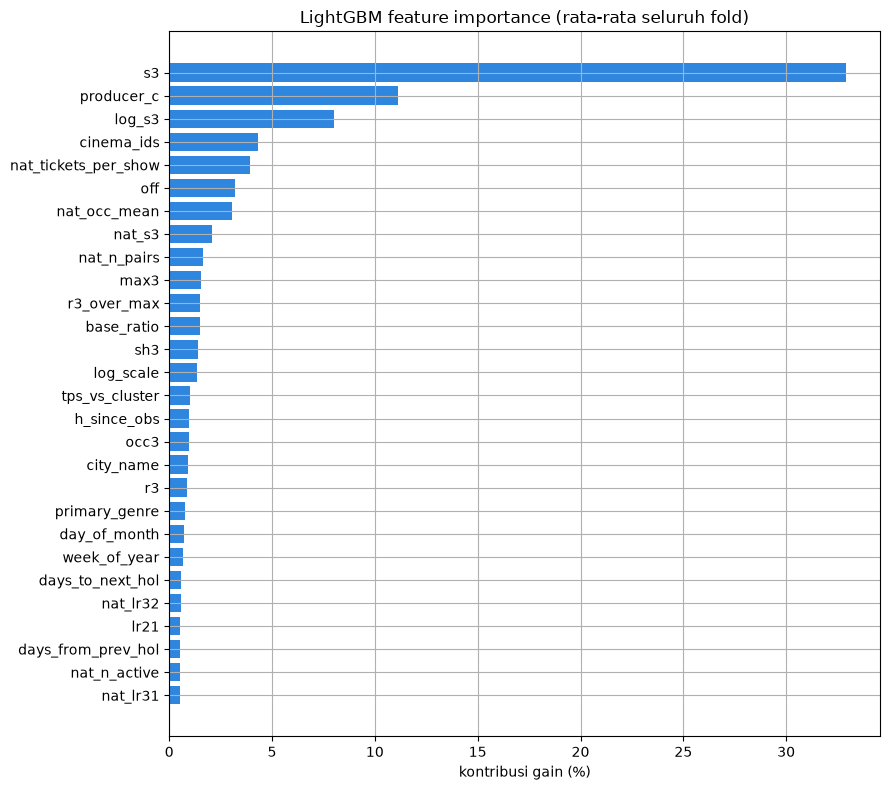


Fitur yang tidak pernah dipakai (5): ['had_history', 'meta_matched', 'fmt_premium', 'fmt_dub', 'fmt_rerelease']
Kontribusi gain 10 fitur teratas: 71.8%


In [20]:
_imp = pd.DataFrame({"feature": FEATS, "gain": 0.0, "split": 0.0})
for _m in fold_models:
    _imp["gain"] += _m.feature_importance(importance_type="gain")
    _imp["split"] += _m.feature_importance(importance_type="split")
_imp["gain"] /= len(fold_models)
_imp["split"] /= len(fold_models)
_imp["gain_pct"] = 100 * _imp["gain"] / _imp["gain"].sum()
_imp = _imp.sort_values("gain", ascending=False).reset_index(drop=True)

print("30 fitur teratas berdasarkan gain:")
print(_imp.head(30)[["feature", "gain_pct", "split"]].round(2).to_string(index=False))

_top = _imp.head(28).iloc[::-1]
plt.figure(figsize=(9, 8))
plt.barh(_top["feature"], _top["gain_pct"], color="#2e86de")
plt.xlabel("kontribusi gain (%)")
plt.title("LightGBM feature importance (rata-rata seluruh fold)")
plt.tight_layout()
plt.show()

_zero = _imp[_imp["split"] == 0]["feature"].tolist()
print(f"\nFitur yang tidak pernah dipakai ({len(_zero)}): {_zero}")
print(f"Kontribusi gain 10 fitur teratas: {_imp.head(10)['gain_pct'].sum():.1f}%")

## 13. Diagnosis Pergeseran Distribusi & Rezim Jendela

In [21]:
from sklearn.metrics import roc_auc_score

PAIR_KEYS = ["anchor_id", "cinema_ids"]
_TRAIN_MIN = train["date_show"].min()

ROW_LEVEL_FEATS = {
    "off", "h_since_obs", "dow", "is_weekend", "is_friday", "is_holiday", "is_nonwork",
    "nonwork_run_len", "days_to_next_hol", "days_from_prev_hol", "month", "day_of_month",
    "week_of_year", "day_tipe", "holiday_tipe", "holiday_name", "cal_factor_global",
    "g_dow_factor", "cl_dow_factor", "cf_target", "uplift", "uplift_global",
    "prior_ratio", "base_ratio", "ticket_price", "price_rel",
}
# Fitur yang menandai film/rumah produksi tertentu. Film uji punya rumah produksi yang
# sebagian besar tak ada di train, jadi fitur ini tidak bisa digeneralisasi.
ID_LIKE_FEATS = ["producer_c", "producer_freq", "title_len", "title_n_words"]

PHASE_FEATS = [c for c in FEATS if c not in ROW_LEVEL_FEATS]
DYN_FEATS = [c for c in PHASE_FEATS if c not in ID_LIKE_FEATS]
print(f"Fitur level pasangan : {len(PHASE_FEATS)} | tanpa identitas: {len(DYN_FEATS)}")

_uniq = lambda cols: list(dict.fromkeys(cols))
P_tr = X_tr.loc[X_tr["off"] == 4,
                _uniq(PAIR_KEYS + ["movie_title", "anchor_lag", "m_first"] + PHASE_FEATS)
                ].reset_index(drop=True)
P_te = X_te.loc[X_te["off"] == 4, _uniq(PAIR_KEYS + PHASE_FEATS)].reset_index(drop=True)
assert not P_tr.columns.duplicated().any() and not P_te.columns.duplicated().any()
print(f"Pasangan latih: {len(P_tr):,} | pasangan uji: {len(P_te):,}")

Fitur level pasangan : 114 | tanpa identitas: 110
Pasangan latih: 137,799 | pasangan uji: 10,373


### 13a. Validasi adversarial

**Cara membacanya dengan benar.** Dengan ~110 fitur dan pasangan latih/uji yang berasal
dari film berbeda pada tanggal berbeda, AUC mendekati 1,0 adalah hal yang **wajar** dan
bukan alarm — setiap agregat level film memang berbeda karena filmnya memang lain.
AUC tinggi **tidak** membuktikan hubungan `P(y | fitur)` bergeser, dan itulah satu-satunya
pergeseran yang benar-benar merusak model. Yang berguna dari cell ini adalah **urutan
fiturnya**: ia menunjukkan *ke arah mana* data uji berbeda, sehingga kita bisa menilai
apakah perbedaan itu sudah tertangani fitur lain atau belum.

In [22]:
def adversarial_auc(feats, tag):
    Xa = pd.concat([P_tr[feats], P_te[feats]], ignore_index=True)
    ya = np.r_[np.zeros(len(P_tr)), np.ones(len(P_te))]
    cats = [c for c in CAT_COLS if c in feats]
    rs = np.random.RandomState(SEED)
    perm = rs.permutation(len(Xa))
    cut = int(0.7 * len(Xa))
    ia, iv = perm[:cut], perm[cut:]
    prm = dict(objective="binary", metric="auc", learning_rate=0.05, num_leaves=63,
               min_data_in_leaf=100, feature_fraction=0.8, bagging_fraction=0.8,
               bagging_freq=1, lambda_l2=5.0, verbosity=-1, num_threads=-1,
               seed=SEED, bagging_seed=SEED + 1, feature_fraction_seed=SEED + 2,
               deterministic=True, force_row_wise=True)
    d1 = lgb.Dataset(Xa.iloc[ia], label=ya[ia], categorical_feature=cats)
    d2 = lgb.Dataset(Xa.iloc[iv], label=ya[iv], categorical_feature=cats, reference=d1)
    m = lgb.train(prm, d1, num_boost_round=800, valid_sets=[d2],
                  callbacks=[lgb.early_stopping(60, verbose=False)])
    auc = roc_auc_score(ya[iv], m.predict(Xa.iloc[iv]))
    imp = pd.DataFrame({"feature": feats, "gain": m.feature_importance("gain")})
    imp["gain_pct"] = 100 * imp["gain"] / max(imp["gain"].sum(), 1e-9)
    imp = imp.sort_values("gain", ascending=False)
    print(f"[{tag}] AUC adversarial = {auc:.4f}")
    print(imp.head(8)[["feature", "gain_pct"]].round(2).to_string(index=False))
    del Xa, d1, d2
    gc.collect()
    return auc, imp


ADV_AUC, _adv_imp_all = adversarial_auc(PHASE_FEATS, "semua fitur")
print()
ADV_AUC_DYN, _adv_imp_dyn = adversarial_auc(DYN_FEATS, "tanpa fitur identitas")

# Yang informatif: SEBERAPA BESAR pergeseran tiap fitur teratas, bukan nilai AUC-nya.
print("\nPergeseran kuantil pada fitur yang paling membedakan:")
_rows = []
for _f in _adv_imp_dyn.head(8)["feature"]:
    if _f in CAT_COLS:
        continue
    _a, _b = P_tr[_f].astype(float), P_te[_f].astype(float)
    _rows.append({"feature": _f,
                  "latih_p50": _a.median(), "uji_p50": _b.median(),
                  "latih_p10": _a.quantile(.1), "uji_p10": _b.quantile(.1),
                  "latih_p90": _a.quantile(.9), "uji_p90": _b.quantile(.9)})
print(pd.DataFrame(_rows).round(3).to_string(index=False))
print("\nPergeseran pada gcf_obs*/base_gcf adalah komposisi hari D1-D3 -- ini memang sudah")
print("dirancang untuk diserap fitur `uplift`, jadi tidak perlu tindakan khusus.")

[semua fitur] AUC adversarial = 0.9997
             feature  gain_pct
          producer_c     52.35
            base_gcf      5.72
nat_tickets_per_show      4.78
       n_active_days      3.88
           title_len      3.54
            gcf_obs3      3.28
        nat_occ_mean      2.45
       producer_freq      2.34

[tanpa fitur identitas] AUC adversarial = 0.9999
             feature  gain_pct
            gcf_obs3     13.63
nat_tickets_per_show     12.75
          nat_shows3      7.53
        nat_occ_mean      6.95
       primary_genre      4.71
       n_active_days      4.54
         nat_n_pairs      3.88
             cf_obs3      3.64

Pergeseran kuantil pada fitur yang paling membedakan:
             feature  latih_p50  uji_p50  latih_p10  uji_p10  latih_p90  uji_p90
            gcf_obs3      1.017    1.203      0.721    1.118      1.307    1.307
nat_tickets_per_show     34.897   18.250     15.055    7.273     79.591   48.501
          nat_shows3   1323.000 2019.000    176.000  58

### 13b. Klasifikasi rezim: jendela pembukaan atau bukan?

Target biner `anchor_lag <= 2` versus `>= 6`; rentang 3–5 dibuang **saat latih** supaya
batas kelasnya tajam, tapi tetap **diprediksi** supaya estimasi komposisi nanti mencakup
keempat rezim. Grup CV memakai rumah produksi, sama seperti model utama.

In [23]:
OPEN_MAX_LAG, LATE_MIN_LAG = 2, 6
A = P_tr.loc[(P_tr["m_first"] > _TRAIN_MIN).values].reset_index(drop=True)
_a_lag = A["anchor_lag"].values
_a_use = (_a_lag <= OPEN_MAX_LAG) | (_a_lag >= LATE_MIN_LAG)
_a_y = (_a_lag <= OPEN_MAX_LAG).astype(int)
REG_ORDER = ["buka (0-2)", "awal (3-5)", "tengah (6-15)", "akhir (16+)"]
_a_reg = np.where(_a_lag <= 2, REG_ORDER[0], np.where(_a_lag <= 5, REG_ORDER[1],
                  np.where(_a_lag <= 15, REG_ORDER[2], REG_ORDER[3])))
print(f"Pasangan umur sahih: {len(A):,} | dipakai latih klasifikasi: {int(_a_use.sum()):,}")

_reg_params = dict(objective="binary", metric="auc", learning_rate=0.05, num_leaves=127,
                   min_data_in_leaf=80, feature_fraction=0.8, bagging_fraction=0.8,
                   bagging_freq=1, lambda_l2=5.0, verbosity=-1, num_threads=-1,
                   seed=SEED, bagging_seed=SEED + 1, feature_fraction_seed=SEED + 2,
                   deterministic=True, force_row_wise=True)
_reg_cats = [c for c in CAT_COLS if c in DYN_FEATS]

oof_open = np.zeros(len(A), dtype=np.float64)
_reg_iters = []
for _tri, _vai in GroupKFold(n_splits=5).split(A, groups=group_keys(A["movie_title"].values)):
    _t = _tri[_a_use[_tri]]                       # latih hanya pada kelas yang tajam
    _d1 = lgb.Dataset(A.loc[_t, DYN_FEATS], label=_a_y[_t], categorical_feature=_reg_cats)
    _v = _vai[_a_use[_vai]]
    _d2 = lgb.Dataset(A.loc[_v, DYN_FEATS], label=_a_y[_v], categorical_feature=_reg_cats,
                      reference=_d1)
    _mr = lgb.train(_reg_params, _d1, num_boost_round=2000, valid_sets=[_d2],
                    callbacks=[lgb.early_stopping(80, verbose=False)])
    oof_open[_vai] = _mr.predict(A.loc[_vai, DYN_FEATS], num_iteration=_mr.best_iteration)
    _reg_iters.append(_mr.best_iteration)

REGIME_AUC = roc_auc_score(_a_y[_a_use], oof_open[_a_use])
REGIME_TRUSTED = REGIME_AUC >= 0.70
print(f"\nAUC out-of-fold klasifikasi rezim: {REGIME_AUC:.4f} | REGIME_TRUSTED = {REGIME_TRUSTED}")

_mfull = lgb.train(_reg_params, lgb.Dataset(A.loc[_a_use, DYN_FEATS], label=_a_y[_a_use],
                                            categorical_feature=_reg_cats),
                   num_boost_round=int(np.mean(_reg_iters)))
P_te["p_open"] = _mfull.predict(P_te[DYN_FEATS])

Pasangan umur sahih: 122,159 | dipakai latih klasifikasi: 105,600

AUC out-of-fold klasifikasi rezim: 0.8534 | REGIME_TRUSTED = True


### 13c. Estimasi komposisi rezim data uji (empat rezim, bukan dua)

Dua rezim tidak cukup: rezim "awal (3–5)" punya MASE di antara keduanya, dan kalau ia
dimasukkan ke kelompok "sudah berjalan" maka estimasinya akan terlalu optimistis.
Jadi kalibrasinya dilakukan per desil `p_open`: untuk setiap desil dihitung **distribusi
keempat rezim yang sebenarnya** di data latih, lalu ditimbang dengan sebaran desil data uji.

Perkiraan komposisi rezim:
               latih (anchor kita)  uji (diperkirakan)
buka (0-2)                    11.3                13.7
awal (3-5)                    13.6                14.1
tengah (6-15)                 45.3                43.7
akhir (16+)                   29.9                28.5

Rata-rata p_open mentah -> latih 0.104 | uji 0.173


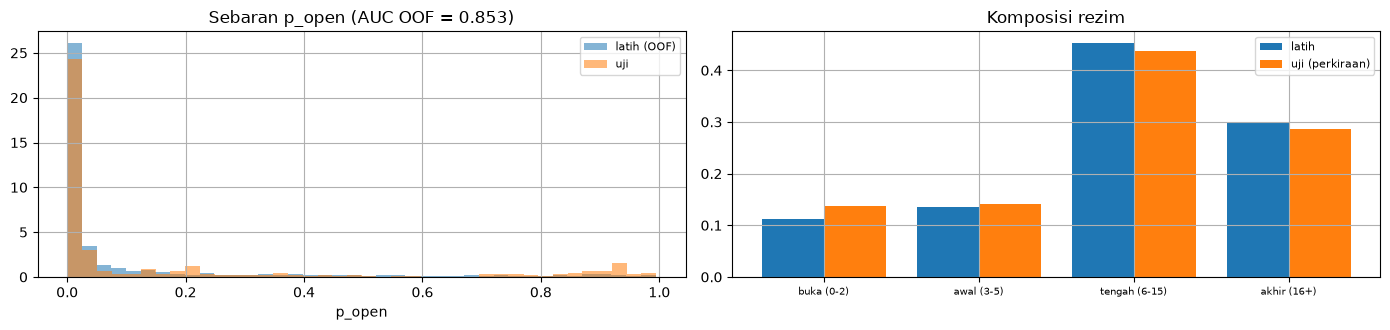

In [24]:
_edges = np.unique(np.quantile(oof_open, np.linspace(0, 1, 11)))
_b_tr = np.digitize(oof_open, _edges[1:-1])
_b_te = np.digitize(P_te["p_open"].values, _edges[1:-1])

_dist = pd.crosstab(_b_tr, _a_reg, normalize="index").reindex(columns=REG_ORDER).fillna(0.0)
_share_te = pd.Series(_b_te).value_counts(normalize=True)
_common = _dist.index.intersection(_share_te.index)
if len(_common) and _share_te.loc[_common].sum() > 0:
    _w_te = _share_te.loc[_common] / _share_te.loc[_common].sum()
    REGIME_SHARE_TEST = (_dist.loc[_common].T * _w_te).T.sum()
else:
    print("PERINGATAN: desil latih & uji tidak bertemu; pakai komposisi data latih.")
    REGIME_SHARE_TEST = pd.Series(_a_reg).value_counts(normalize=True).reindex(REG_ORDER).fillna(0.0)
REGIME_SHARE_TEST = (REGIME_SHARE_TEST / REGIME_SHARE_TEST.sum()).reindex(REG_ORDER).fillna(0.0)

REGIME_SHARE_TRAIN = pd.Series(_a_reg).value_counts(normalize=True).reindex(REG_ORDER).fillna(0.0)
print("Perkiraan komposisi rezim:")
print(pd.DataFrame({"latih (anchor kita)": REGIME_SHARE_TRAIN,
                    "uji (diperkirakan)": REGIME_SHARE_TEST}).mul(100).round(1).to_string())
print(f"\nRata-rata p_open mentah -> latih {oof_open.mean():.3f} | uji {P_te['p_open'].mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 3.4))
ax[0].hist(oof_open, bins=40, density=True, alpha=.55, label="latih (OOF)")
ax[0].hist(P_te["p_open"], bins=40, density=True, alpha=.55, label="uji")
ax[0].set_xlabel("p_open"); ax[0].legend(fontsize=8)
ax[0].set_title(f"Sebaran p_open (AUC OOF = {REGIME_AUC:.3f})")
_xr = np.arange(len(REG_ORDER))
ax[1].bar(_xr - 0.2, REGIME_SHARE_TRAIN.values, width=0.4, label="latih")
ax[1].bar(_xr + 0.2, REGIME_SHARE_TEST.values, width=0.4, label="uji (perkiraan)")
ax[1].set_xticks(_xr); ax[1].set_xticklabels(REG_ORDER, fontsize=7); ax[1].legend(fontsize=8)
ax[1].set_title("Komposisi rezim")
plt.tight_layout(); plt.show()

### 13d. MASE per rezim dan estimasi untuk data uji

In [25]:
_lag_rows = X_tr["anchor_lag"].values
OK_AGE_ROWS = (X_tr["m_first"] > _TRAIN_MIN).values
_reg_by_lag = np.where(_lag_rows <= 2, REG_ORDER[0], np.where(_lag_rows <= 5, REG_ORDER[1],
                       np.where(_lag_rows <= 15, REG_ORDER[2], REG_ORDER[3])))
# Film left-censored sudah tayang sebelum data dimulai, jadi jendelanya PASTI bukan
# pembukaan walau anchor_lag-nya kecil. Dipetakan ke "tengah" supaya barisnya tetap terpakai
# dan tidak salah dihitung sebagai contoh pembukaan.
REGIME_ROWS = np.where(OK_AGE_ROWS, _reg_by_lag, REG_ORDER[2])


def mase_by_regime(pred):
    e = np.abs(y_ratio - np.asarray(pred, dtype=np.float64))
    return (pd.DataFrame({"r": REGIME_ROWS, "e": e}).groupby("r")["e"]
            .agg(MASE="mean", n="size").reindex(REG_ORDER))


def regime_weighted_mase(pred):
    """MASE yang ditimbang ke komposisi rezim data uji -- inilah target sebenarnya."""
    m = mase_by_regime(pred)
    return float((m["MASE"].fillna(0.0) * REGIME_SHARE_TEST).sum())


MASE_BY_REGIME = mase_by_regime(oof_final)
print("MASE OOF per rezim:")
print(MASE_BY_REGIME.assign(porsi_uji=REGIME_SHARE_TEST,
                            kontribusi=lambda d: d["MASE"] * REGIME_SHARE_TEST
                            ).round(4).to_string())

MASE_OPEN = float(MASE_BY_REGIME.loc[REG_ORDER[0], "MASE"])
MASE_LATER = float(MASE_BY_REGIME.loc[[REG_ORDER[2], REG_ORDER[3]], "MASE"].mean())
MASE_EST_TEST = regime_weighted_mase(oof_final) if REGIME_TRUSTED else float(
    np.mean([MASE_OPEN, MASE_LATER]))

print(f"\nMASE OOF apa adanya (campuran anchor pilihan kita) : {FINAL_OOF_MASE:.4f}")
print(f"MASE holdout waktu                                  : {HOLDOUT_MASE_CAL:.4f}")
print("-" * 62)
print(f"Batas bawah  (semua jendela uji sudah berjalan)      : {MASE_LATER:.4f}")
print(f"Batas atas   (semua jendela uji pembukaan)           : {MASE_OPEN:.4f}")
print(f"Estimasi 4-rezim                                    : {MASE_EST_TEST:.4f}  <== ESTIMASI")
print("-" * 62)
_contrib = (MASE_BY_REGIME["MASE"].fillna(0) * REGIME_SHARE_TEST) / max(MASE_EST_TEST, 1e-9)
print("Porsi error yang disumbang tiap rezim pada estimasi:")
print((_contrib * 100).round(1).to_string())

MASE OOF per rezim:
                 MASE       n  porsi_uji  kontribusi
r                                                   
buka (0-2)     0.9000   96649     0.1369      0.1232
awal (3-5)     0.5861  115913     0.1408      0.0825
tengah (6-15)  0.3755  496671     0.4368      0.1640
akhir (16+)    0.3742  255360     0.2855      0.1068

MASE OOF apa adanya (campuran anchor pilihan kita) : 0.4530
MASE holdout waktu                                  : 0.4133
--------------------------------------------------------------
Batas bawah  (semua jendela uji sudah berjalan)      : 0.3749
Batas atas   (semua jendela uji pembukaan)           : 0.9000
Estimasi 4-rezim                                    : 0.4766  <== ESTIMASI
--------------------------------------------------------------
Porsi error yang disumbang tiap rezim pada estimasi:
r
buka (0-2)       25.9
awal (3-5)       17.3
tengah (6-15)    34.4
akhir (16+)      22.4


### 13e. MASE menurut rezim × ukuran pasangan

In [26]:
_ct = pd.DataFrame({
    "rezim": pd.Categorical(REGIME_ROWS, categories=REG_ORDER),
    "scale_bin": pd.cut(X_tr["scale"].values, [0, 2, 5, 10, 25, 50, 1e9],
                        labels=["<=2", "2-5", "5-10", "10-25", "25-50", ">50"]),
    "err": np.abs(y_ratio - oof_final),
})
print("MASE (baris = rezim, kolom = ukuran pasangan):")
print(_ct.pivot_table(index="rezim", columns="scale_bin", values="err",
                      aggfunc="mean", observed=False).round(3).to_string())
print("\nJumlah baris:")
print(_ct.pivot_table(index="rezim", columns="scale_bin", values="err",
                      aggfunc="size", observed=False).to_string())

# p_open disiapkan sebagai kandidat fitur untuk Cell 14
P_tr["p_open"] = np.nan
P_tr.loc[(P_tr["m_first"] > _TRAIN_MIN).values, "p_open"] = oof_open
P_tr["p_open"] = P_tr["p_open"].fillna(float(np.median(oof_open)))
X_tr = X_tr.merge(P_tr[PAIR_KEYS + ["p_open"]], on=PAIR_KEYS, how="left")
X_te = X_te.merge(P_te[PAIR_KEYS + ["p_open"]], on=PAIR_KEYS, how="left")
assert len(X_tr) == len(y_ratio), "Jumlah baris X_tr berubah setelah merge p_open!"
for _d in (X_tr, X_te):
    _d["p_open"] = _d["p_open"].fillna(float(np.median(oof_open))).astype(np.float32)

del _mfull, A
gc.collect()

MASE (baris = rezim, kolom = ukuran pasangan):
scale_bin        <=2    2-5   5-10  10-25  25-50    >50
rezim                                                  
buka (0-2)     0.533  0.672  0.995  1.304  1.555  0.650
awal (3-5)     0.587  0.335  0.640  0.740  0.962  0.492
tengah (6-15)  0.544  0.401  0.586  0.401  0.540  0.339
akhir (16+)    1.572  0.740  0.457  0.456  0.413  0.319

Jumlah baris:
scale_bin       <=2   2-5   5-10  10-25  25-50     >50
rezim                                                 
buka (0-2)     1211  2989   5124  12600  15701   59024
awal (3-5)     1197  2961   5215  12061  15862   78617
tengah (6-15)  4935  9835  17325  39599  48699  376278
akhir (16+)    3178  5775  10500  24563  30744  180600


5618

## 14. Penimbangan Ulang ke Komposisi Rezim Data Uji

Ini perubahan paling berdampak di seluruh notebook, dan alasannya murni aritmetika.

MASE adalah **rata-rata sederhana** atas baris. Kalau komposisi rezim data uji berbeda dari
komposisi data latih, maka meminimalkan MASE pada campuran data latih berarti
mengoptimalkan besaran yang salah. Koreksi yang tepat untuk itu adalah **importance
weighting**: beri tiap baris bobot `porsi_uji(rezim) / porsi_latih(rezim)`, sehingga loss
training menjadi penduga tak-bias bagi MASE di data uji.

Ini bukan trik — ini definisi. Dan kebetulan ia menyerang titik yang paling menyakitkan:
rezim pembukaan punya MASE jauh terburuk **dan** porsinya di data uji lebih besar daripada
di data latih, jadi selama ini model justru paling sedikit memperhatikannya.

In [27]:
FEATS_BASE = list(FEATS)
CFG_BASE = dict(oof=oof, oof_b=oof_b, oof_h=oof_h, best_iters=best_iters,
                iters_b=iters_b, iters_h=iters_h, BLEND_NAMES=BLEND_NAMES, BLEND_W=BLEND_W,
                ZERO_SNAP=ZERO_SNAP, CAL_MULT=CAL_MULT, oof_final=oof_final,
                OOF_MASE_FINAL=OOF_MASE_FINAL, OOF_MASE_ROUND=OOF_MASE_ROUND,
                USE_ROUND=USE_ROUND, mase=FINAL_OOF_MASE)

# ---------------------------------------------------------------- bobot importance
_share_rows = pd.Series(REGIME_ROWS).value_counts(normalize=True).reindex(REG_ORDER).fillna(0.0)
_wmap = (REGIME_SHARE_TEST / _share_rows.replace(0.0, np.nan)).fillna(0.0)
MAX_W = 8.0
_wmap = _wmap.clip(upper=MAX_W)          # cegah beberapa baris mendominasi seluruh loss
W_REGIME = pd.Series(REGIME_ROWS).map(_wmap).fillna(1.0).values.astype(np.float64)
W_REGIME = W_REGIME / W_REGIME.mean()

print("Bobot per rezim:")
print(pd.DataFrame({"porsi_latih_baris": _share_rows, "porsi_uji": REGIME_SHARE_TEST,
                    "bobot": _wmap}).round(3).to_string())
print(f"\nBobot baris: min {W_REGIME.min():.3f} | median {np.median(W_REGIME):.3f} | "
      f"maks {W_REGIME.max():.3f}")
print(f"Ukuran sampel efektif: {W_REGIME.sum() ** 2 / (W_REGIME ** 2).sum() / len(W_REGIME):.1%} "
      "dari jumlah baris")

Bobot per rezim:
               porsi_latih_baris  porsi_uji  bobot
buka (0-2)                 0.100      0.137  1.366
awal (3-5)                 0.120      0.141  1.172
tengah (6-15)              0.515      0.437  0.848
akhir (16+)                0.265      0.285  1.078

Bobot baris: min 0.848 | median 0.848 | maks 1.366
Ukuran sampel efektif: 97.0% dari jumlah baris


Ukuran sampel efektif di atas adalah biayanya: penimbangan membuang sebagian daya
statistik demi membidik distribusi yang benar. Kalau angkanya jatuh di bawah ~40%,
`MAX_W` sebaiknya diturunkan supaya pertukarannya tidak terlalu merugikan.

In [28]:
# ------------------------------------------------------------- perbandingan konfigurasi
_feats_clean = [c for c in FEATS_BASE if c not in ID_LIKE_FEATS]
CONFIGS = {
    "base, tanpa bobot": (FEATS_BASE, None),
    "base + bobot rezim": (FEATS_BASE, W_REGIME),
    "tanpa identitas + bobot rezim": (_feats_clean, W_REGIME),
    "tanpa identitas + bobot + p_open": (_feats_clean + ["p_open"], W_REGIME),
}
_FOLDS_SEL = list(GroupKFold(n_splits=3).split(Xm, y_train_lab, groups=groups))

_sel = {}
for _name, (_f, _w) in CONFIGS.items():
    Xm = X_tr[_f]
    _o, _ = run_cv(LGB_PARAMS, tag=f"seleksi: {_name}", folds=_FOLDS_SEL, weights=_w)
    _sel[_name] = {"MASE_polos": mase_ratio(y_ratio, _o),
                   "MASE_tertimbang": regime_weighted_mase(_o),
                   "n_fitur": len(_f)}

_cmp = pd.DataFrame(_sel).T
print("\nPerbandingan konfigurasi (CV 3 fold, grup rumah produksi):")
print(_cmp.astype(float).round(4).to_string())
print("\nKriteria = MASE_tertimbang (perkiraan skor data uji), BUKAN MASE_polos.")
print("Wajar kalau MASE_polos memburuk saat bobot dipakai: itu memang konsekuensi")
print("berhenti mengoptimalkan campuran data latih yang tidak relevan.")

BEST_CFG = min(_sel, key=lambda k: _sel[k]["MASE_tertimbang"])
_margin = _sel["base, tanpa bobot"]["MASE_tertimbang"] - _sel[BEST_CFG]["MASE_tertimbang"]
print(f"\nTerbaik: '{BEST_CFG}' | perbaikan dari base: {_margin:+.4f}")

MIN_MARGIN = 0.005
if _margin < MIN_MARGIN and BEST_CFG != "base, tanpa bobot":
    _tie = {k: v for k, v in _sel.items()
            if v["MASE_tertimbang"] - _sel[BEST_CFG]["MASE_tertimbang"] < MIN_MARGIN}
    BEST_CFG = min(_tie, key=lambda k: _sel[k]["n_fitur"])
    print(f"Selisih dalam derau (<{MIN_MARGIN}) -> pilih yang paling sederhana: '{BEST_CFG}'")

FEATS, W_USED = CONFIGS[BEST_CFG]
Xm = X_tr[FEATS]
USE_PHASE = BEST_CFG.endswith("p_open")
USE_WEIGHTS = W_USED is not None
print(f"\nFinal: '{BEST_CFG}' | {len(FEATS)} fitur | bobot: {USE_WEIGHTS} | p_open: {USE_PHASE}")

# ------------------------------------------------------------------- latih ulang penuh
if BEST_CFG == "base, tanpa bobot":
    print("Base menang -> hasil CV Cell 10 dipakai apa adanya.")
else:
    # samakan objektif blending & kalibrasi dengan objektif pelatihan
    OBJ_MASE = "tertimbang" if USE_WEIGHTS else "polos"
    print(f"Melatih ulang CV penuh (5 fold), objektif blend/kalibrasi = {OBJ_MASE}...")
    oof, best_iters = run_cv(LGB_PARAMS, tag="A final", weights=W_USED)
    oof_b, iters_b = run_cv(PARAMS_B, tag="B final", weights=W_USED)
    oof_h, iters_h = run_cv_per_horizon(PARAMS_H, tag="H final", fallback=oof, weights=W_USED)

    BLEND_NAMES, BLEND_W, oof_blend, _bm = fit_blend({"A": oof, "B": oof_b, "H": oof_h})
    ZERO_SNAP, CAL_MULT, _ = fit_calibration(oof_blend, w=W_USED)
    oof_final = apply_post(oof_blend, OFF_ARR)
    OOF_MASE_FINAL = mase_ratio(y_ratio, oof_final)

    _sc_arr = X_tr["scale"].values
    OOF_MASE_ROUND = mase_ratio(y_ratio, np.round(oof_final * _sc_arr) / _sc_arr)
    USE_ROUND = OOF_MASE_ROUND < OOF_MASE_FINAL
    FINAL_OOF_MASE = min(OOF_MASE_FINAL, OOF_MASE_ROUND)
    HOLDOUT_MASE_RAW, HOLDOUT_MASE_CAL, _ = run_time_holdout(tag="final")
    RESULTS_ROWS.append({"tahap": f"Blend final ({BEST_CFG})", "OOF_MASE": OOF_MASE_FINAL})

[seleksi: base, tanpa bobot] OOF MASE = 0.4723 | mean best_iter = 697
[seleksi: base + bobot rezim] OOF MASE = 0.4761 | mean best_iter = 341
[seleksi: tanpa identitas + bobot rezim] OOF MASE = 0.4611 | mean best_iter = 486
[seleksi: tanpa identitas + bobot + p_open] OOF MASE = 0.4632 | mean best_iter = 537

Perbandingan konfigurasi (CV 3 fold, grup rumah produksi):
                                  MASE_polos  MASE_tertimbang  n_fitur
base, tanpa bobot                     0.4723           0.4959    140.0
base + bobot rezim                    0.4761           0.5000    140.0
tanpa identitas + bobot rezim         0.4611           0.4851    136.0
tanpa identitas + bobot + p_open      0.4632           0.4869    137.0

Kriteria = MASE_tertimbang (perkiraan skor data uji), BUKAN MASE_polos.
Wajar kalau MASE_polos memburuk saat bobot dipakai: itu memang konsekuensi
berhenti mengoptimalkan campuran data latih yang tidak relevan.

Terbaik: 'tanpa identitas + bobot rezim' | perbaikan dari base: 

**Catatan penting soal `fit_blend` dan `fit_calibration`.** Keduanya masih meminimalkan
MASE polos, bukan MASE tertimbang. Kalau penimbangan terbukti membantu, langkah
penyempurnaan berikutnya adalah mengganti `mase_ratio` di dalam kedua fungsi itu dengan
`regime_weighted_mase` agar seluruh rantai optimasi konsisten pada satu besaran.

In [29]:
MASE_BY_REGIME = mase_by_regime(oof_final)
MASE_EST_TEST = (regime_weighted_mase(oof_final) if REGIME_TRUSTED
                 else float(np.mean([MASE_BY_REGIME["MASE"].iloc[0],
                                     MASE_BY_REGIME["MASE"].iloc[[2, 3]].mean()])))
MASE_OPEN = float(MASE_BY_REGIME.loc[REG_ORDER[0], "MASE"])
MASE_LATER = float(MASE_BY_REGIME.loc[[REG_ORDER[2], REG_ORDER[3]], "MASE"].mean())

_before = CFG_BASE["oof_final"]
print("\nMASE per rezim: sebelum -> sesudah")
print(pd.DataFrame({"sebelum": mase_by_regime(_before)["MASE"],
                    "sesudah": MASE_BY_REGIME["MASE"],
                    "porsi_uji": REGIME_SHARE_TEST}).round(4).to_string())

RESULTS = pd.DataFrame(RESULTS_ROWS)
print("\n" + "=" * 66)
print(f"{'Konfigurasi terpakai':<42s} {BEST_CFG}")
print(f"{'MASE OOF polos':<42s} {FINAL_OOF_MASE:.4f}")
print(f"{'MASE holdout waktu':<42s} {HOLDOUT_MASE_CAL:.4f}")
print(f"{'Estimasi MASE data uji (4 rezim)':<42s} {MASE_EST_TEST:.4f}")
print(f"{'  sebelum penimbangan':<42s} {regime_weighted_mase(_before):.4f}")
print(f"{'  rentang (berjalan ... pembukaan)':<42s} {MASE_LATER:.4f} ... {MASE_OPEN:.4f}")
print("=" * 66)

gc.collect()


MASE per rezim: sebelum -> sesudah
               sebelum  sesudah  porsi_uji
buka (0-2)      0.9000   0.8838     0.1369
awal (3-5)      0.5861   0.5683     0.1408
tengah (6-15)   0.3755   0.3657     0.4368
akhir (16+)     0.3742   0.3616     0.2855

Konfigurasi terpakai                       tanpa identitas + bobot rezim
MASE OOF polos                             0.4408
MASE holdout waktu                         0.3986
Estimasi MASE data uji (4 rezim)           0.4640
  sebelum penimbangan                      0.4766
  rentang (berjalan ... pembukaan)         0.3636 ... 0.8838


0

## 15. Model Dua Bagian untuk Baris Nol

Lever terbesar yang belum disentuh. Porsi baris bernilai nol naik dari ~29% di D4 ke ~58%
di D10 — jadi separuh masalah ini sebenarnya soal **apakah film masih tayang**, bukan soal
berapa tiket terjual.

Loss L1 sudah menangani nol secara implisit (ia menduga median kondisional, yang menjadi 0
begitu `P(y = 0) > 0.5`). Tapi satu model harus memakai kapasitas yang sama untuk dua
pertanyaan yang sifatnya berbeda. Memisahkannya:

* **Pengklasifikasi** `P(y = 0)` — murni soal keputusan penjadwalan bioskop.
* **Regresor L1** pada baris positif saja — murni soal besaran permintaan.

Penggabungannya mengikuti teori MAE: prediksi optimal adalah kuantil ke
`(0.5 − p₀) / (1 − p₀)` dari distribusi positif. Kuantil per baris tidak bisa dilatih
langsung, jadi didekati dengan **pengali per desil `p₀`** yang dicari pada OOF — dan karena
nilai 0 ikut dalam grid pengali, aturan "prediksi nol saat `p₀` tinggi" muncul sendiri dari
data, tanpa ambang yang ditetapkan manual.

In [30]:
RUN_TWOPART = True

PARAMS_CLF = dict(objective="binary", metric="binary_logloss", learning_rate=0.05,
                  num_leaves=127, min_data_in_leaf=150, feature_fraction=0.70,
                  bagging_fraction=0.80, bagging_freq=1, lambda_l2=3.0,
                  verbosity=-1, num_threads=-1, force_row_wise=True,
                  seed=SEED + 303, bagging_seed=SEED + 304,
                  feature_fraction_seed=SEED + 305, deterministic=True)
PARAMS_POS = dict(LGB_PARAMS)
PARAMS_POS.update(learning_rate=0.04, num_leaves=160, min_data_in_leaf=120,
                  seed=SEED + 404)


def run_cv_twopart(folds=None, weights=None, tag="Z"):
    folds = _FOLDS if folds is None else folds
    p0 = np.zeros(len(X_tr), dtype=np.float64)
    pos = np.zeros(len(X_tr), dtype=np.float64)
    it_c, it_r = [], []
    _is_zero = (y_ratio == 0).astype(int)
    for _f, (_tri, _vai) in enumerate(folds):
        # --- bagian 1: peluang nol
        _d1 = lgb.Dataset(Xm.iloc[_tri], label=_is_zero[_tri],
                          weight=None if weights is None else weights[_tri],
                          categorical_feature=cats_in(Xm.columns), free_raw_data=True)
        _d2 = lgb.Dataset(Xm.iloc[_vai], label=_is_zero[_vai],
                          weight=None if weights is None else weights[_vai],
                          categorical_feature=cats_in(Xm.columns), reference=_d1,
                          free_raw_data=True)
        _mc = lgb.train(PARAMS_CLF, _d1, num_boost_round=3000, valid_sets=[_d2],
                        callbacks=[lgb.early_stopping(120, verbose=False)])
        p0[_vai] = _mc.predict(Xm.iloc[_vai], num_iteration=_mc.best_iteration)
        it_c.append(_mc.best_iteration)
        del _d1, _d2, _mc

        # --- bagian 2: besaran, hanya dari baris positif
        _pp = _tri[y_ratio[_tri] > 0]
        _vp = _vai[y_ratio[_vai] > 0]
        _d1 = lgb.Dataset(Xm.iloc[_pp], label=y_train_lab[_pp],
                          weight=None if weights is None else weights[_pp],
                          categorical_feature=cats_in(Xm.columns), free_raw_data=True)
        _d2 = lgb.Dataset(Xm.iloc[_vp], label=y_ratio[_vp],
                          weight=None if weights is None else weights[_vp],
                          categorical_feature=cats_in(Xm.columns), reference=_d1,
                          free_raw_data=True)
        _mr = lgb.train(PARAMS_POS, _d1, num_boost_round=5000, valid_sets=[_d2],
                        callbacks=[lgb.early_stopping(150, verbose=False)])
        pos[_vai] = _mr.predict(Xm.iloc[_vai], num_iteration=_mr.best_iteration)
        it_r.append(_mr.best_iteration)
        del _d1, _d2, _mr
        print(f"  [{tag}] fold {_f + 1}/{len(folds)} selesai")
        gc.collect()
    return np.clip(p0, 0, 1), np.clip(pos, 0, None), it_c, it_r


def fit_twopart_combiner(p0, pos, w=None, n_bucket=10):
    """Pengali per desil p0, dicari pada OOF. Grid memuat 0 supaya 'ramal nol' bisa terpilih."""
    w = np.ones(len(y_ratio)) if w is None else np.asarray(w, dtype=np.float64)
    edges = np.unique(np.quantile(p0, np.linspace(0, 1, n_bucket + 1)))
    inner = edges[1:-1] if len(edges) > 2 else np.array([0.5])
    b = np.digitize(p0, inner)
    grid = np.r_[0.0, np.arange(0.40, 1.61, 0.05)]
    mult = {}
    for k in np.unique(b):
        m = b == k
        errs = [float(np.average(np.abs(y_ratio[m] - c * pos[m]), weights=w[m])) for c in grid]
        mult[int(k)] = float(grid[int(np.argmin(errs))])
    return inner, mult


def apply_twopart(p0, pos, inner, mult):
    b = np.digitize(np.asarray(p0), inner)
    f = pd.Series(b).map(mult).fillna(1.0).values
    return np.clip(np.asarray(pos) * f, 0, None)


if RUN_TWOPART:
    oof_p0, oof_pos, ITERS_CLF, ITERS_POS = run_cv_twopart(weights=W_USED, tag="Z")
    from sklearn.metrics import roc_auc_score as _auc
    print(f"\nAUC pengklasifikasi nol (OOF): {_auc((y_ratio == 0).astype(int), oof_p0):.4f}")
    print(f"  porsi baris nol sebenarnya: {(y_ratio == 0).mean():.1%}")

    TP_EDGES, TP_MULT = fit_twopart_combiner(oof_p0, oof_pos, w=W_USED)
    print("Pengali per desil p0 (0 = ramal nol):")
    print({k: round(v, 2) for k, v in sorted(TP_MULT.items())})

    oof_z = apply_twopart(oof_p0, oof_pos, TP_EDGES, TP_MULT)
    print(f"\n[Z dua bagian] MASE polos      = {mase_ratio(y_ratio, oof_z):.4f}")
    print(f"[Z dua bagian] MASE tertimbang = {regime_weighted_mase(oof_z):.4f}")
    print(f"[blend saat ini] {OBJ_MASE} = {obj_mase(oof_final):.4f}")

    # ------------------------------------------------- blend ulang dengan Z
    _cands = {"A": oof, "B": oof_b, "H": oof_h, "Z": oof_z}
    _n2, _w2, _blend2, _m2 = fit_blend(_cands)
    _zs2, _mu2, _ = fit_calibration(_blend2, w=W_USED)
    _final2 = apply_post(_blend2, OFF_ARR, zero_snap=_zs2, mult=_mu2)

    _before = obj_mase(oof_final)
    _after = obj_mase(_final2)
    print(f"\nObjektif ({OBJ_MASE}): {_before:.4f} -> {_after:.4f} ({_after - _before:+.4f})")

    USE_TWOPART = _after < _before
    if USE_TWOPART:
        BLEND_NAMES, BLEND_W = _n2, _w2
        oof_blend, ZERO_SNAP, CAL_MULT = _blend2, _zs2, _mu2
        oof_final = _final2
        OOF_MASE_FINAL = mase_ratio(y_ratio, oof_final)
        _sc_arr = X_tr["scale"].values
        OOF_MASE_ROUND = mase_ratio(y_ratio, np.round(oof_final * _sc_arr) / _sc_arr)
        USE_ROUND = OOF_MASE_ROUND < OOF_MASE_FINAL
        FINAL_OOF_MASE = min(OOF_MASE_FINAL, OOF_MASE_ROUND)
        MASE_BY_REGIME = mase_by_regime(oof_final)
        MASE_EST_TEST = regime_weighted_mase(oof_final)
        MASE_OPEN = float(MASE_BY_REGIME.loc[REG_ORDER[0], "MASE"])
        MASE_LATER = float(MASE_BY_REGIME.loc[[REG_ORDER[2], REG_ORDER[3]], "MASE"].mean())
        HOLDOUT_MASE_RAW, HOLDOUT_MASE_CAL, _ = run_time_holdout(tag="final + Z")
        RESULTS_ROWS.append({"tahap": "Blend + model dua bagian", "OOF_MASE": OOF_MASE_FINAL})
        RESULTS = pd.DataFrame(RESULTS_ROWS)
        print(f"Model dua bagian DIPAKAI (bobot {dict(zip(_n2, np.round(_w2, 3)))})")
    else:
        print("Model dua bagian tidak membantu -> konfigurasi Cell 14 dipertahankan.")
else:
    USE_TWOPART = False
    print("RUN_TWOPART = False, dilewati.")

print(f"\n>>> MASE OOF polos      : {FINAL_OOF_MASE:.4f}")
print(f">>> Estimasi data uji   : {MASE_EST_TEST:.4f}")
print(f">>> MASE holdout waktu  : {HOLDOUT_MASE_CAL:.4f}")
gc.collect()

  [Z] fold 1/5 selesai
  [Z] fold 2/5 selesai
  [Z] fold 3/5 selesai
  [Z] fold 4/5 selesai
  [Z] fold 5/5 selesai

AUC pengklasifikasi nol (OOF): 0.9339
  porsi baris nol sebenarnya: 43.5%
Pengali per desil p0 (0 = ramal nol):
{0: 1.05, 1: 1.0, 2: 1.0, 3: 0.9, 4: 0.7, 5: 0.4, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0}

[Z dua bagian] MASE polos      = 0.4359
[Z dua bagian] MASE tertimbang = 0.4601
[blend saat ini] tertimbang = 0.4640
Bobot blend terbaik {'A': np.float64(0.0), 'B': np.float64(0.0), 'H': np.float64(0.25), 'Z': np.float64(0.75)} -> tertimbang MASE 0.4589
zero-snap terbaik = 0.16 | pengali per horizon = {4: 1.01, 5: 1.01, 6: 1.01, 7: 1.03, 8: 1.01, 9: 1.01, 10: 1.0}

Objektif (tertimbang): 0.4640 -> 0.4566 (-0.0074)
[final + Z] holdout MASE: mentah 0.3996 | terkalibrasi 0.3978 (136 fitur, 475 ronde)
Model dua bagian DIPAKAI (bobot {'A': np.float64(0.0), 'B': np.float64(0.0), 'H': np.float64(0.25), 'Z': np.float64(0.75)})

>>> MASE OOF polos      : 0.4328
>>> Estimasi data uji   : 0.

0

## 16. Latih Ulang pada Seluruh Data & Prediksi Data Uji

Model final dilatih ulang memakai **100%** sampel latih (bukan 80% seperti di fold),
dengan jumlah ronde = rata-rata `best_iteration` dari CV × 1,10 sebagai kompensasi
bertambahnya data. Tiap komponen dirata-rata atas beberapa seed untuk mengurangi
varians, lalu digabung memakai bobot blend dan kalibrasi yang sudah terpilih.

Komponen yang bobot blend-nya nol **tidak dilatih ulang** — tidak ada gunanya
membayar waktu latih untuk model yang tidak ikut dipakai.

In [31]:
Xm_te = X_te[FEATS]
assert list(Xm_te.columns) == list(Xm.columns), "Urutan kolom fitur latih vs uji berbeda!"

SEEDS_A = [SEED, SEED + 1, SEED + 2]
SEEDS_B = [SEED + 101, SEED + 102]
_FULL_MULT = 1.10

W_MAP = dict(zip(BLEND_NAMES, BLEND_W))
NEEDED = [n for n in BLEND_NAMES if W_MAP[n] > 1e-9]
print(f"Bobot blend: { {k: round(float(v), 3) for k, v in W_MAP.items()} }")
print(f"Komponen yang dilatih ulang: {NEEDED}")

pred_map = {}


def _fit_full_global(params, seeds, n_rounds, tag):
    out = np.zeros(len(X_te), dtype=np.float64)
    print(f"{tag}: {len(seeds)} seed × {n_rounds} ronde")
    for _s in seeds:
        _p = dict(params)
        _p.update(seed=_s, bagging_seed=_s + 1, feature_fraction_seed=_s + 2)
        _d = lgb.Dataset(Xm, label=y_train_lab, categorical_feature=cats_in(Xm.columns), free_raw_data=True)
        _m = lgb.train(_p, _d, num_boost_round=n_rounds)
        out += _m.predict(Xm_te) / len(seeds)
        del _d, _m
        gc.collect()
    out = np.clip(out, 0, None)
    print(f"  selesai. rata-rata rasio prediksi = {out.mean():.3f}")
    return out


if "A" in NEEDED:
    pred_map["A"] = _fit_full_global(LGB_PARAMS, SEEDS_A,
                                    max(int(np.mean(best_iters) * _FULL_MULT), 200), "Model A")
if "B" in NEEDED:
    pred_map["B"] = _fit_full_global(PARAMS_B, SEEDS_B,
                                     max(int(np.mean(iters_b) * _FULL_MULT), 200), "Model B")

if "Z" in NEEDED:
    print("Model Z (dua bagian):")
    _nz_c = max(int(np.mean(ITERS_CLF) * _FULL_MULT), 200)
    _nz_r = max(int(np.mean(ITERS_POS) * _FULL_MULT), 200)
    _is_zero_full = (y_ratio == 0).astype(int)
    _dz = lgb.Dataset(Xm, label=_is_zero_full,
                      weight=None if W_USED is None else W_USED,
                      categorical_feature=cats_in(Xm.columns), free_raw_data=True)
    _mz_c = lgb.train(PARAMS_CLF, _dz, num_boost_round=_nz_c)
    _te_p0 = np.clip(_mz_c.predict(Xm_te), 0, 1)
    del _dz, _mz_c
    gc.collect()

    _pos_idx = np.flatnonzero(y_ratio > 0)
    _dz = lgb.Dataset(Xm.iloc[_pos_idx], label=y_train_lab[_pos_idx],
                      weight=None if W_USED is None else W_USED[_pos_idx],
                      categorical_feature=cats_in(Xm.columns), free_raw_data=True)
    _mz_r = lgb.train(PARAMS_POS, _dz, num_boost_round=_nz_r)
    _te_pos = np.clip(_mz_r.predict(Xm_te), 0, None)
    del _dz, _mz_r
    gc.collect()

    pred_map["Z"] = apply_twopart(_te_p0, _te_pos, TP_EDGES, TP_MULT)
    print(f"  klasifikasi {_nz_c} ronde, regresi positif {_nz_r} ronde")
    print(f"  porsi prediksi nol dari model Z: {(pred_map['Z'] == 0).mean():.1%}")

if "H" in NEEDED:
    _pred_h = np.zeros(len(X_te), dtype=np.float64)
    _off_te = X_te["off"].values
    print("Model H (per horizon):")
    for _hh in range(4, 11):
        _t = np.flatnonzero(OFF_ARR == _hh)
        _v = np.flatnonzero(_off_te == _hh)
        if len(_v) == 0:
            continue
        if len(_t) < 500 or _hh not in iters_h:
            _pred_h[_v] = pred_map.get("A", np.ones(len(X_te)))[_v]
            print(f"  horizon D{_hh}: data latih kurang -> pakai fallback")
            continue
        _n_h = max(int(np.mean(iters_h[_hh]) * _FULL_MULT), 150)
        _d = lgb.Dataset(Xm.iloc[_t], label=y_train_lab[_t],
                         categorical_feature=cats_in(Xm.columns), free_raw_data=True)
        _m = lgb.train(PARAMS_H, _d, num_boost_round=_n_h)
        _pred_h[_v] = _m.predict(Xm_te.iloc[_v])
        print(f"  horizon D{_hh}: {_n_h} ronde, {len(_t):,} baris latih -> {len(_v):,} prediksi")
        del _d, _m
        gc.collect()
    pred_map["H"] = np.clip(_pred_h, 0, None)

# --------------------------------------------------------------------- blending
pred_ratio = np.zeros(len(X_te), dtype=np.float64)
for _nm in NEEDED:
    pred_ratio += W_MAP[_nm] * pred_map[_nm]

# ------------------------------------------------- kalibrasi -> jumlah tiket
pred_ratio_cal = apply_post(pred_ratio, X_te["off"].values)
pred_tickets = pred_ratio_cal * X_te["scale"].values
if USE_ROUND:
    pred_tickets = np.round(pred_tickets)
pred_tickets = np.clip(pred_tickets, 0, None)

X_te["pred_total_ticket"] = pred_tickets
print(f"\nPorsi prediksi tepat nol : {(pred_tickets == 0).mean():.2%}")
print("Statistik prediksi tiket:")
print(pd.Series(pred_tickets).describe(percentiles=[.5, .9, .99]).round(2).to_string())

# ------------------------------------------------------------------- submission
submission = sample_submission[["id"]].merge(
    X_te[["id", "pred_total_ticket"]].rename(columns={"pred_total_ticket": "total_ticket"}),
    on="id", how="left")
print(f"\nBaris submission tanpa prediksi: {int(submission['total_ticket'].isna().sum())}")
submission["total_ticket"] = submission["total_ticket"].fillna(0.0)
if USE_ROUND:
    submission["total_ticket"] = submission["total_ticket"].astype(np.int64)

print(f"\nDataFrame submission siap: {submission.shape}")
print(submission.head(10).to_string(index=False))
print("\nPenulisan submission.csv dilakukan di sel terakhir notebook.")

Bobot blend: {'A': 0.0, 'B': 0.0, 'H': 0.25, 'Z': 0.75}
Komponen yang dilatih ulang: ['H', 'Z']
Model Z (dua bagian):
  klasifikasi 233 ronde, regresi positif 1056 ronde
  porsi prediksi nol dari model Z: 38.7%
Model H (per horizon):
  horizon D4: 2206 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D5: 597 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D6: 352 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D7: 445 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D8: 240 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D9: 531 ronde, 137,799 baris latih -> 10,373 prediksi
  horizon D10: 254 ronde, 137,799 baris latih -> 10,373 prediksi

Porsi prediksi tepat nol : 41.53%
Statistik prediksi tiket:
count    72611.00
mean       138.04
std        436.89
min          0.00
50%         24.00
90%        334.00
99%       1659.90
max      29184.00

Baris submission tanpa prediksi: 0

DataFrame submission siap: (72611, 2)
 id  total_ticket
  1            33


## 17. Pemeriksaan Akhir Submission & Ringkasan

Pemeriksaan di bawah menangkap kesalahan yang paling sering lolos: id tidak lengkap,
nilai negatif/NaN, dan — yang paling penting — **bentuk prediksi yang tidak masuk akal**
dibanding pola historis (mis. model malah menaikkan permintaan di hari kerja).

Jumlah baris submission : 72611 | seharusnya: 72611
id unik                 : 72611
id cocok dengan sample  : True
NaN                     : 0
Nilai negatif           : 0

Rata-rata rasio prediksi per horizon (bandingkan dengan tabel EDA Cell 3):
     mean_rasio  median_rasio  porsi_nol
off                                     
4         0.952         0.912      0.106
5         0.686         0.630      0.173
6         0.440         0.468      0.254
7         0.344         0.325      0.380
8         0.183         0.000      0.588
9         0.142         0.000      0.689
10        0.132         0.000      0.717

Rata-rata rasio prediksi per hari-dalam-minggu (akhir pekan harus lebih tinggi):
Senin     0.506
Selasa    0.468
Rabu      0.239
Kamis     0.160
Jumat     0.128
Sabtu     0.578
Minggu    0.801


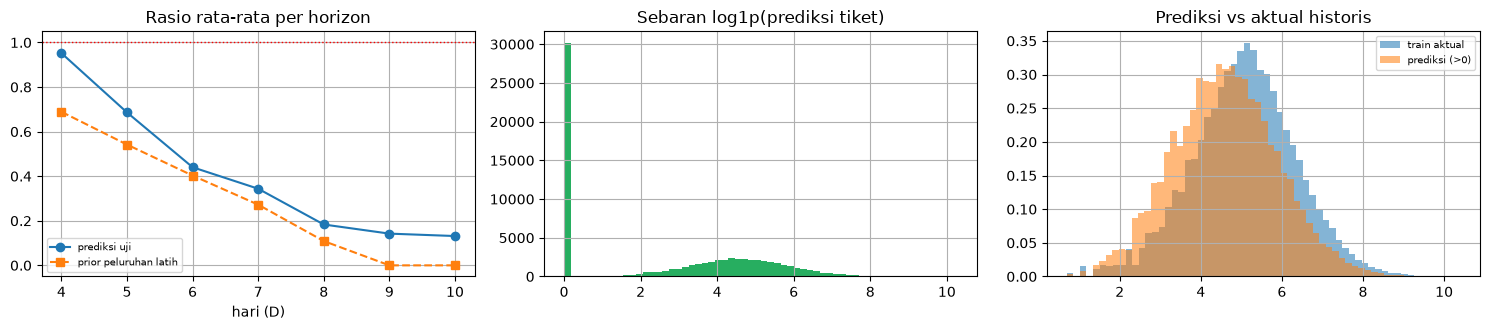


                            RINGKASAN HASIL                             
                                      tahap  OOF_MASE
                Baseline terbaik (analitik)    0.6281
                      Model A (LGBM global)    0.4697
                   Model B (params berbeda)    0.4693
                      Model H (per horizon)    0.4670
                                Blend A+B+H    0.4654
                          Blend + kalibrasi    0.4530
             Blend + kalibrasi + pembulatan    0.4530
Blend final (tanpa identitas + bobot rezim)    0.4409
                   Blend + model dua bagian    0.4328
------------------------------------------------------------------------
MASE baseline naif (pred = scale)                    0.9098
MASE OOF (GroupKFold per film)                       0.4328
MASE holdout waktu (film terbaru)                    0.3978
------------------------------------------------------------------------
Estimasi MASE data uji (per rezim)  <== ESTIMASI     0.4566


In [32]:
# ---- validitas format --------------------------------------------------------
print("Jumlah baris submission :", len(submission), "| seharusnya:", len(sample_submission))
print("id unik                 :", submission["id"].nunique())
print("id cocok dengan sample  :", set(submission["id"]) == set(sample_submission["id"]))
print("NaN                     :", int(submission["total_ticket"].isna().sum()))
print("Nilai negatif           :", int((submission["total_ticket"] < 0).sum()))
assert len(submission) == len(sample_submission)
assert submission["total_ticket"].isna().sum() == 0
assert (submission["total_ticket"] >= 0).all()

# ---- bentuk prediksi vs pola historis ---------------------------------------
_chk = X_te[["off", "dow", "is_holiday", "scale", "pred_total_ticket"]].copy()
_chk["pred_ratio"] = _chk["pred_total_ticket"] / _chk["scale"]

print("\nRata-rata rasio prediksi per horizon (bandingkan dengan tabel EDA Cell 3):")
print(_chk.groupby("off")["pred_ratio"].agg(mean_rasio="mean", median_rasio="median",
                                            porsi_nol=lambda s: float((s == 0).mean())
                                            ).round(3).to_string())

print("\nRata-rata rasio prediksi per hari-dalam-minggu (akhir pekan harus lebih tinggi):")
_dw = _chk.groupby("dow")["pred_ratio"].mean()
_dw.index = [["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"][i] for i in _dw.index]
print(_dw.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
_g = _chk.groupby("off")["pred_ratio"].mean()
ax[0].plot(_g.index, _g.values, "o-", label="prediksi uji")
ax[0].plot(DECAY_PRIOR.index, DECAY_PRIOR.values, "s--", label="prior peluruhan latih")
ax[0].axhline(1.0, color="r", ls=":", lw=1)
ax[0].set_title("Rasio rata-rata per horizon"); ax[0].set_xlabel("hari (D)"); ax[0].legend(fontsize=7)
ax[1].hist(np.log1p(submission["total_ticket"]), bins=60, color="#27ae60")
ax[1].set_title("Sebaran log1p(prediksi tiket)")
ax[2].hist(np.log1p(train["total_ticket"]), bins=60, alpha=.55, density=True, label="train aktual")
ax[2].hist(np.log1p(submission.loc[submission["total_ticket"] > 0, "total_ticket"]),
           bins=60, alpha=.55, density=True, label="prediksi (>0)")
ax[2].legend(fontsize=7); ax[2].set_title("Prediksi vs aktual historis")
plt.tight_layout(); plt.show()

# ---- ringkasan akhir ---------------------------------------------------------
print("\n" + "=" * 72)
print("RINGKASAN HASIL".center(72))
print("=" * 72)
print(RESULTS.round(4).to_string(index=False))
print("-" * 72)
print(f"{'MASE baseline naif (pred = scale)':<52s} "
      f"{BASELINE_TABLE.loc[BASELINE_TABLE['baseline'].str.startswith('B0'), 'MASE'].iloc[0]:.4f}")
print(f"{'MASE OOF (GroupKFold per film)':<52s} {FINAL_OOF_MASE:.4f}")
print(f"{'MASE holdout waktu (film terbaru)':<52s} {HOLDOUT_MASE_CAL:.4f}")
print("-" * 72)
print(f"{'Estimasi MASE data uji (per rezim)  <== ESTIMASI':<52s} {MASE_EST_TEST:.4f}")
print(f"{'  batas bawah (semua jendela sudah berjalan)':<52s} {MASE_LATER:.4f}")
print(f"{'  batas atas  (semua jendela pembukaan)':<52s} {MASE_OPEN:.4f}")
print("-" * 72)
print("Perkiraan komposisi rezim data uji dan sumbangan error-nya:")
print(pd.DataFrame({"porsi_uji": REGIME_SHARE_TEST,
                    "MASE_rezim": MASE_BY_REGIME["MASE"],
                    "sumbangan": MASE_BY_REGIME["MASE"].fillna(0) * REGIME_SHARE_TEST}
                   ).round(4).to_string())
print("-" * 72)
print(f"{'Kumpulan fitur terpilih':<52s} {BEST_CFG}")
print(f"{'Bobot rezim dipakai?':<52s} {USE_WEIGHTS}")
print(f"{'AUC adversarial (semua fitur / tanpa identitas)':<52s} {ADV_AUC:.3f} / {ADV_AUC_DYN:.3f}")
print(f"{'AUC klasifikasi rezim (dipercaya?)':<52s} {REGIME_AUC:.3f} / {REGIME_TRUSTED}")
print("=" * 72)

**Angka mana yang harus dipercaya?** Perhatikan **rentang** batas bawah–batas atas,
bukan hanya satu angka. MASE OOF apa adanya adalah rata-rata atas campuran anchor yang
kita tentukan sendiri, jadi ia bukan estimasi leaderboard. Rentang per rezim jauh lebih
informatif: batas bawah berlaku kalau jendela D1–D3 film uji semuanya jatuh di
pertengahan masa tayang, batas atas kalau semuanya di pembukaan. Lebarnya rentang itu
adalah ketidakpastian yang nyata, dan tidak bisa dihilangkan dengan model yang lebih besar
— hanya dengan informasi tambahan tentang posisi D1 terhadap tanggal rilis.

In [33]:
_target_hit = [t for t in (0.5, 0.4, 0.3) if MASE_EST_TEST < t]
if _target_hit:
    print(f"Estimasi titik menembus < {min(_target_hit)}; batas atas rentang "
          f"{MASE_OPEN:.4f} tetap perlu diingat sebagai skenario terburuk.")
else:
    print(f"Estimasi titik {MASE_EST_TEST:.4f} belum menembus 0.5.")
print("File siap dikirim: submission.csv")

Estimasi titik menembus < 0.5; batas atas rentang 0.8894 tetap perlu diingat sebagai skenario terburuk.
File siap dikirim: submission.csv


### Langkah lanjutan, diurutkan berdasarkan dampak

1. **Samakan campuran anchor dengan rezim data uji.** Kalau Cell 13 memperkirakan porsi
   jendela pembukaan di data uji jauh berbeda dari porsi di data latih, ubah `ANCHOR_LAGS`
   di Cell 6 agar rapat di rezim yang relevan dan jarang di luar. MASE berbeda lebih dari
   2x antar rezim, jadi mengubah komposisi data latih lebih berpengaruh daripada
   mengubah arsitektur model.
2. **Model dua bagian untuk baris nol.** Porsi baris nol naik dari ~29% di D4 ke ~58%
   di D10. Latih pengklasifikasi `P(y = 0)` lalu regresor L1 khusus baris positif, dan
   gabungkan sebagai `pred = 0 jika P(y=0) >= 0.5, selain itu prediksi positif`.
   Tambahkan hasilnya sebagai kandidat baru di `fit_blend`. Loss L1 sudah menangani nol
   secara implisit, jadi ini penajaman — bukan perbaikan mendasar.
3. **Segmentasi berdasarkan tabel silang rezim × `scale` (Cell 13e).** Kalau satu sel
   punya MASE jauh di atas sel lain dan jumlah barisnya besar, latih model terpisah untuk
   segmen tersebut.
4. **Tuning hyperparameter** — lakukan paling akhir. Dampaknya jauh lebih kecil
   daripada tiga poin di atas.

**Yang jangan dilakukan:**

* Menambah fitur yang butuh informasi setelah D3 (umur film sebenarnya,
  `occupation_rate`/`total_show` hari target, agregat dari hari D4+). Fitur seperti itu
  akan menaikkan skor validasi dan menjatuhkan skor leaderboard.
* Mengejar MASE OOF sebagai angka utama. Cell 14 sudah menunjukkan bahwa OOF bisa
  **membaik** karena fitur yang bocor antar fold sekaligus **memburuk** dalam hal
  generalisasi. Untuk kompetisi ini, holdout waktu adalah kriteria yang lebih jujur.

## 18. Output Akhir — `submission.csv`

Sel terakhir sengaja hanya melakukan satu hal: memvalidasi lalu menulis berkas submission.
Dengan begitu output paling bawah notebook adalah berkas yang dikirim, dan panitia yang
menjalankan ulang notebook bisa langsung melihat hasilnya tanpa menelusuri sel lain.

### Catatan reproducibility

Panitia mensyaratkan hasil yang bisa dibuat ulang, dan disparitas bisa berujung
diskualifikasi. Semua sumber keacakan di notebook ini sudah dipaku ke `SEED`, dan
LightGBM dijalankan dengan `deterministic=True` + `force_row_wise=True` supaya angkanya
tidak bergeser di mesin dengan jumlah core CPU berbeda.

In [34]:
print("=" * 62)
print("RINGKASAN REPRODUCIBILITY".center(62))
print("=" * 62)
print(f"SEED global              : {SEED}  (np.random.seed dipasang di Cell 1)")
print(f"LightGBM deterministic   : {LGB_PARAMS.get('deterministic')}")
print(f"LightGBM force_row_wise  : {LGB_PARAMS.get('force_row_wise')}")
print("Seed tiap komponen:")
for _nm, _pp in ([("Model A", LGB_PARAMS), ("Model B", PARAMS_B), ("Model H", PARAMS_H)]
                 + ([("Z klasifikasi", PARAMS_CLF), ("Z regresi", PARAMS_POS)]
                    if RUN_TWOPART else [])):
    print(f"  {_nm:<15s} seed={_pp.get('seed')} bagging_seed={_pp.get('bagging_seed')} "
          f"feature_fraction_seed={_pp.get('feature_fraction_seed')}")
print(f"Seed multi-seed refit    : A={SEEDS_A} B={SEEDS_B}")
print(f"Pembagian fold           : GroupKFold deterministik, grup={CV_GROUP_BY}")
print(f"Subsample & permutasi    : np.random.RandomState({SEED})")
print("=" * 62)

                  RINGKASAN REPRODUCIBILITY                   
SEED global              : 2026  (np.random.seed dipasang di Cell 1)
LightGBM deterministic   : True
LightGBM force_row_wise  : True
Seed tiap komponen:
  Model A         seed=2026 bagging_seed=2027 feature_fraction_seed=2028
  Model B         seed=2127 bagging_seed=2033 feature_fraction_seed=2039
  Model H         seed=2228 bagging_seed=2027 feature_fraction_seed=2028
  Z klasifikasi   seed=2329 bagging_seed=2330 feature_fraction_seed=2331
  Z regresi       seed=2430 bagging_seed=2027 feature_fraction_seed=2028
Seed multi-seed refit    : A=[2026, 2027, 2028] B=[2127, 2128]
Pembagian fold           : GroupKFold deterministik, grup=producer
Subsample & permutasi    : np.random.RandomState(2026)


### Validasi & penulisan berkas

Format yang diminta kompetisi:

```
id,total_ticket
1,100
2,101
3,102
```

In [35]:
SUB_PATH = "submission.csv"

sub = submission[["id", "total_ticket"]].copy()
sub["total_ticket"] = pd.to_numeric(sub["total_ticket"], errors="coerce").fillna(0.0).clip(lower=0)
if USE_ROUND:
    sub["total_ticket"] = sub["total_ticket"].round().astype(np.int64)

_checks = {
    "jumlah baris == sample_submission": len(sub) == len(sample_submission),
    "id unik": sub["id"].nunique() == len(sub),
    "himpunan id identik": set(sub["id"]) == set(sample_submission["id"]),
    "urutan id sama dengan sample": sub["id"].tolist() == sample_submission["id"].tolist(),
    "tanpa NaN": bool(sub.notna().all().all()),
    "tanpa nilai negatif": bool((sub["total_ticket"] >= 0).all()),
    "semua nilai berhingga": bool(np.isfinite(sub["total_ticket"].to_numpy()).all()),
    "nama & urutan kolom benar": list(sub.columns) == ["id", "total_ticket"],
}
print("Validasi berkas submission:")
for _k, _v in _checks.items():
    print(f"  [{'OK   ' if _v else 'GAGAL'}] {_k}")
assert all(_checks.values()), "Validasi submission GAGAL -- berkas tidak ditulis."

sub.to_csv(SUB_PATH, index=False)
print(f"\n{SUB_PATH} tersimpan | {len(sub):,} baris | "
      f"{os.path.getsize(SUB_PATH) / 1024:,.1f} KB")

print("\n--- 10 baris pertama berkas yang benar-benar tertulis di disk ---")
with open(SUB_PATH, encoding="utf-8") as _fh:
    for _i, _line in enumerate(_fh):
        if _i >= 11:
            break
        print(_line.rstrip())

_reload = pd.read_csv(SUB_PATH)
print(f"\nDibaca ulang: {_reload.shape} | dtype total_ticket = {_reload['total_ticket'].dtype}")
print("\nStatistik prediksi:")
print(_reload["total_ticket"].describe(percentiles=[.25, .5, .75, .9, .99]).round(2).to_string())
print(f"\nPorsi prediksi tepat nol : {(_reload['total_ticket'] == 0).mean():.2%}")
print(f"Total tiket diprediksi   : {_reload['total_ticket'].sum():,.0f}")
print(f"\nMASE OOF {FINAL_OOF_MASE:.4f} | holdout {HOLDOUT_MASE_CAL:.4f} | "
      f"estimasi uji {MASE_EST_TEST:.4f}")
print(f"BERKAS SIAP DIKIRIM: {os.path.abspath(SUB_PATH)}")

Validasi berkas submission:
  [OK   ] jumlah baris == sample_submission
  [OK   ] id unik
  [OK   ] himpunan id identik
  [OK   ] urutan id sama dengan sample
  [OK   ] tanpa NaN
  [OK   ] tanpa nilai negatif
  [OK   ] semua nilai berhingga
  [OK   ] nama & urutan kolom benar

submission.csv tersimpan | 72,611 baris | 689.2 KB

--- 10 baris pertama berkas yang benar-benar tertulis di disk ---
id,total_ticket
1,33
2,24
3,0
4,0
5,0
6,0
7,0
8,69
9,58
10,0

Dibaca ulang: (72611, 2) | dtype total_ticket = int64

Statistik prediksi:
count    72611.00
mean       138.04
std        436.89
min          0.00
25%          0.00
50%         24.00
75%        123.00
90%        334.00
99%       1659.90
max      29184.00

Porsi prediksi tepat nol : 41.53%
Total tiket diprediksi   : 10,023,536

MASE OOF 0.4328 | holdout 0.3978 | estimasi uji 0.4566
BERKAS SIAP DIKIRIM: c:\PROJECT\KAGGLE\JOINT\submission.csv
